# | Updating Models based on input data to achieve better accuracy

For models trained on David Bowie, we have train 17 predict 15 and train 15 predict 17 and thus we have corrected predictions...



In [ ]:
# using logic from postanalysis_review.py we will pull select frames from the labeled data to retrain our algorithms
# Three types of logics to implement:
# 1. Pull frames from data in random fashion
# 2. Pull frames from data to maximize displacement capture
# 3. Pull frames from data using DINO embedding to maximize embedding space coverage


In [1]:
# pull data from each of the 3 logics and save as new csv files to be used for retraining the algorithms
# pull from:
# img stack - C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\TrainingData_T17
# C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\ExperimentEval\UFBatch\TrainT15_EvalT17\DavidBowie_n400_T15_snapshot150
# C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\ExperimentEval\UFBatch\TrainT15_EvalT17\DavidBowie_n400_T15_snapshot125
# Updated - C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\TrainingData_T15\CollectedData_Trial15_DB.csv

# img stack - C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\TrainingData_T15
# Pred 1 - C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\ExperimentEval\UFBatch\TrainT17_EvalT15\DavidBowie_n400_T17_snapshot125
# Pred 2 - C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\ExperimentEval\UFBatch\TrainT17_EvalT15\DavidBowie_n400_T17_snapshot150
# Updated - C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\TrainingData_T17\2Dpoints_2025_08_25_DavidBowie_Subset_Trial17_UND_matches.csv


In [ ]:
# Frame Selection Logic 1: Random Sampling
# - Randomly select a specified number of frames from the dataset.
# Frame Selection Logic 2: Maximize Displacement Capture
# - Select frames that capture the maximum displacement of key points across the dataset.
# Frame Selection Logic 3: DINO Embedding Space Coverage
# - Use DINO embeddings to select frames that maximize coverage of the embedding space, ensuring a
# diverse set of frames for retraining the algorithms.


# Sampling Helper Functions

In [64]:
# random sampling logic
import os
import random
import pandas as pd
import xrommtools_copy
from os import mkdir
import re
from pathlib import Path
import numpy as np
import glob

# randomly select frames from the dataset
def random_frame_selection(
    dataframe,
    image_folder_path,
    num_frames=50,
    camera_subdir="Cam1",
    image_prefix="Cam1_Img00",
    seed=42,
):
    total_frames = len(dataframe)
    if num_frames > total_frames:
        raise ValueError(f"num_frames ({num_frames}) cannot be greater than total frames ({total_frames})")
    if num_frames <= 0:
        raise ValueError("num_frames must be > 0")

    rng = random.Random(seed)
    selected_indices = sorted(rng.sample(range(total_frames), int(num_frames)))
    trimmed = dataframe.iloc[selected_indices].copy()

    def build_image_index(image_folder_path, camera_subdir="Cam1", image_prefix="Cam1_Img"):
        folder = Path(image_folder_path) / camera_subdir
        files = []
        for ext in (".jpg", ".jpeg", ".png", ".tif", ".tiff"):
            files.extend(folder.glob(f"{image_prefix}*{ext}"))
        return [str(p) for p in sorted(files)]

    def resolve_image_by_folder_index(image_index, idx):
        i = int(idx)
        if 0 <= i < len(image_index):
            return image_index[i]
        return None

    image_index = build_image_index(image_folder_path, camera_subdir=camera_subdir, image_prefix=image_prefix)
    trimmed["image_path"] = [
        resolve_image_by_folder_index(image_index, idx)
        for idx in selected_indices
    ]

    meta = {
        int(i): {
            "label": "Random sample",
        }
        for i in selected_indices
    }

    summary_lines = [
        f"Random {len(selected_indices)} frames",
        f"Source {camera_subdir}",
    ]

    return trimmed, meta, summary_lines

from PIL import Image


def _build_zone_specs(frame_limit, zone_size=400):
    """Create contiguous frame zones used for weighted sampling.

    Parameters
    ----------
    frame_limit : int
        Total number of frames available in the dataframe.
    zone_size : int, default=400
        Number of frames per zone.

    Returns
    -------
    list[dict]
        Zone descriptors with keys: zone_index, start, end, and label.
    """
    starts = list(range(0, frame_limit, zone_size))
    zones = []
    for idx, start in enumerate(starts):
        end = min(start + zone_size, frame_limit)
        zones.append(
            {
                "zone_index": idx,
                "start": int(start),
                "end": int(end),
                "label": f"Z{idx + 1} {start + 1}-{end}",
            }
        )
    return zones


def _allocate_counts(weights, total_count):
    """Distribute an integer frame budget across zones from nonnegative weights.

    Uses floor allocation plus remainder assignment by largest fractional part.
    If all weights are invalid or zero, allocation defaults to uniform.

    Parameters
    ----------
    weights : sequence[float]
        Relative zone importance values.
    total_count : int
        Total number of frames to allocate.

    Returns
    -------
    list[int]
        Integer allocations per weight entry, summing to total_count when possible.
    """
    if total_count <= 0 or len(weights) == 0:
        return [0 for _ in weights]

    w = np.asarray(weights, dtype=float)
    w = np.where(np.isfinite(w) & (w > 0), w, 0.0)
    if float(np.sum(w)) <= 0:
        w = np.ones(len(weights), dtype=float)
    w = w / float(np.sum(w))

    raw = w * int(total_count)
    counts = np.floor(raw).astype(int)
    remaining = int(total_count - np.sum(counts))
    if remaining > 0:
        remainders = raw - counts
        for i in np.argsort(-remainders)[:remaining]:
            counts[int(i)] += 1
    return counts.tolist()


def _zone_for_frame(frame_idx, zones):
    """Return the zone dictionary containing a given frame index.

    Parameters
    ----------
    frame_idx : int
        Frame index to locate.
    zones : list[dict]
        Zone list from _build_zone_specs.

    Returns
    -------
    dict | None
        Matching zone, last zone fallback if out of range, or None when zones is empty.
    """
    for zone in zones:
        if zone["start"] <= frame_idx < zone["end"]:
            return zone
    return zones[-1] if zones else None


def _cam_xy_columns(dataframe, cam="cam1"):
    """Find paired X/Y coordinate columns for one camera.

    Column names are expected to end with '<camera>_X' and '<camera>_Y',
    for example: 'MarkerA_cam1_X', 'MarkerA_cam1_Y'.

    Parameters
    ----------
    dataframe : pandas.DataFrame
        Input points table.
    cam : str, default='cam1'
        Camera token in column suffixes ('cam1', 'cam2', etc.).

    Returns
    -------
    list[tuple[str, str]]
        Sorted (x_col, y_col) pairs where both coordinates exist.
    """
    pat_x = re.compile(rf".+_{cam}_X$")
    pat_y = re.compile(rf".+_{cam}_Y$")
    x_cols = sorted([c for c in dataframe.columns if pat_x.match(str(c))])
    y_cols = sorted([c for c in dataframe.columns if pat_y.match(str(c))])

    x_map = {c.rsplit(f"_{cam}_", 1)[0]: c for c in x_cols}
    y_map = {c.rsplit(f"_{cam}_", 1)[0]: c for c in y_cols}
    keys = sorted(set(x_map).intersection(y_map))
    return [(x_map[k], y_map[k]) for k in keys]


def _frame_displacement_from_df(dataframe, xy_pairs, start_frame, end_frame):
    """Compute mean marker displacement between two frames.

    Displacement is Euclidean distance per marker pair, then averaged across
    markers with finite values at both frames.

    Parameters
    ----------
    dataframe : pandas.DataFrame
        Coordinate table.
    xy_pairs : list[tuple[str, str]]
        (x_col, y_col) pairs for one camera.
    start_frame : int
        Start frame index.
    end_frame : int
        End frame index.

    Returns
    -------
    float | None
        Mean displacement in pixels, or None if not computable.
    """
    if not xy_pairs or start_frame == end_frame:
        return None

    s = dataframe.iloc[int(start_frame)]
    e = dataframe.iloc[int(end_frame)]
    distances = []
    for x_col, y_col in xy_pairs:
        x0 = pd.to_numeric(s[x_col], errors="coerce")
        y0 = pd.to_numeric(s[y_col], errors="coerce")
        x1 = pd.to_numeric(e[x_col], errors="coerce")
        y1 = pd.to_numeric(e[y_col], errors="coerce")
        if np.isfinite(x0) and np.isfinite(y0) and np.isfinite(x1) and np.isfinite(y1):
            distances.append(float(np.hypot(x1 - x0, y1 - y0)))

    if len(distances) == 0:
        return None
    return float(np.mean(distances))


def _load_dino_components(model_name="dinov2_vits14"):
    """Load DINOv2 model + image transform."""
    try:
        import torch
        from torchvision import transforms
    except Exception as exc:
        raise RuntimeError(
            "DINO selection requires torch and torchvision in the active environment."
        ) from exc

    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = torch.hub.load("facebookresearch/dinov2", model_name)
    model.eval().to(device)
    transform = transforms.Compose(
        [
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
        ]
    )
    return {
        "torch": torch,
        "model": model,
        "transform": transform,
        "device": device,
    }


def _compute_dino_embeddings(image_paths, model_name="dinov2_vits14", batch_size=16):
    """Compute L2-normalized DINO embeddings for image files.

    Parameters
    ----------
    image_paths : list[str]
        Ordered list of image paths to embed. Files are loaded in this order and
        output rows preserve the same order.
    model_name : str, default='dinov2_vits14'
        DINOv2 model identifier passed to torch.hub via _load_dino_components.
    batch_size : int, default=16
        Number of images processed per forward pass.

    Returns
    -------
    numpy.ndarray
        Float32 embedding matrix of shape (N, D), where N is the number of
        successfully processed input images and D is the embedding dimension.
        Each row is L2-normalized to unit length.

        Returns np.empty((0, 0), dtype=np.float32) when no embeddings can be
        produced (for example, empty input or all batches skipped).

    Notes
    -----
    - Runs inference under torch.no_grad() and automatically uses CUDA when
      available (configured in _load_dino_components).
    - Handles multiple model output formats: dict, tuple/list, or tensor.
    - This function performs no resizing/cropping logic beyond the transform
      created in _load_dino_components.
    """
    if not image_paths:
        return np.empty((0, 0), dtype=np.float32)

    components = _load_dino_components(model_name=model_name)
    torch = components["torch"]
    model = components["model"]
    transform = components["transform"]
    device = components["device"]

    chunks = []
    for start in range(0, len(image_paths), int(batch_size)):
        batch_paths = image_paths[start:start + int(batch_size)]
        tensors = []
        for p in batch_paths:
            with Image.open(p) as img:
                tensors.append(transform(img.convert("RGB")))
        if not tensors:
            continue

        batch = torch.stack(tensors).to(device)
        with torch.no_grad():
            feats = model(batch)

        if isinstance(feats, dict):
            if "x_norm_clstoken" in feats:
                feats = feats["x_norm_clstoken"]
            else:
                feats = next(iter(feats.values()))
        elif isinstance(feats, (tuple, list)):
            feats = feats[0]

        chunks.append(feats.detach().cpu().numpy())

    if not chunks:
        return np.empty((0, 0), dtype=np.float32)

    emb = np.concatenate(chunks, axis=0).astype(np.float32)
    norms = np.linalg.norm(emb, axis=1, keepdims=True)
    norms = np.maximum(norms, 1e-12)
    return emb / norms


def _k_center_greedy(embeddings, k, seed=42):
    """Select a diverse subset with farthest-first k-center greedy in cosine space.

    Parameters
    ----------
    embeddings : numpy.ndarray
        Array of shape (N, D). Rows are expected to be L2-normalized so that
        cosine distance can be computed as 1 - dot(u, v).
    k : int
        Number of items to select.
    seed : int, default=42
        RNG seed used to choose the first anchor point.

    Returns
    -------
    tuple[list[int], dict[int, float]]
        selected : Indices of selected rows in embedding space order of selection.
        diversity_gain : Mapping selected_index -> gain value, where gain is the
            current farthest minimum distance to the selected set at the moment
            the point is added (first seed point has gain 0.0).

    Behavior
    --------
    - If N <= 0 or k <= 0, returns ([], {}).
    - If k >= N, returns all indices [0..N-1] with zero gains.
    - Otherwise greedily adds the point that maximizes distance to its nearest
      selected center at each step.
    """
    n = int(embeddings.shape[0])
    if n <= 0 or k <= 0:
        return [], {}
    if k >= n:
        return list(range(n)), {int(i): 0.0 for i in range(n)}

    rng = np.random.default_rng(seed)
    first = int(rng.integers(0, n))
    selected = [first]
    diversity_gain = {int(first): 0.0}

    sim = embeddings @ embeddings[first].reshape(-1, 1)
    min_dist = 1.0 - np.squeeze(sim, axis=1)
    min_dist[first] = -np.inf

    for _ in range(k - 1):
        idx = int(np.argmax(min_dist))
        gain = float(min_dist[idx]) if np.isfinite(min_dist[idx]) else 0.0
        selected.append(idx)
        diversity_gain[int(idx)] = max(gain, 0.0)

        dist_to_new = 1.0 - np.squeeze(embeddings @ embeddings[idx].reshape(-1, 1), axis=1)
        min_dist = np.minimum(min_dist, dist_to_new)
        min_dist[selected] = -np.inf

    return selected, diversity_gain


def displacement_frame_selection(
    dataframe,
    image_folder_path,
    num_frames=20,
    zone_size=400,
    camera="cam1",
    camera_subdir="Cam1",
    image_prefix="Cam1_Img00",
    seed=42,
 ):
    """Select frames by displacement-weighted zone sampling.

    Workflow
    --------
    1. Split timeline into fixed-size zones.
    2. Score each zone using average marker displacement from zone start to end.
    3. Allocate frame counts per zone proportional to displacement.
    4. Randomly sample within each zone (seeded), then backfill if needed.
    5. Return selected rows with image_path, per-frame metadata, and summary text.

    Parameters
    ----------
    dataframe : pandas.DataFrame
        Input dataframe containing '<marker>_<camera>_X/Y' columns.
    image_folder_path : str or Path
        Root folder that contains camera image subdirectories.
    num_frames : int, default=20
        Number of frames to select.
    zone_size : int, default=400
        Frame zone size used for displacement scoring.
    camera : str, default='cam1'
        Camera suffix to use when finding coordinate columns.
    camera_subdir : str, default='Cam1'
        Subfolder used to construct output image paths.
    image_prefix : str, default='Cam1_Img'
        Image filename prefix before '.####.jpg'.
    seed : int, default=42
        Random seed for reproducible sampling.

    Returns
    -------
    tuple[pandas.DataFrame, dict, list[str]]
        trimmed : Selected dataframe rows with added 'image_path'.
        meta : Mapping frame_index -> {'label', 'zone_weight', 'avg_displacement'}.
        summary_lines : Human-readable selection summary per zone.

    Raises
    ------
    ValueError
        If no X/Y columns are found for the requested camera.
    """
    frame_limit = len(dataframe)
    count = min(int(num_frames), int(frame_limit))
    zones = _build_zone_specs(frame_limit, zone_size=zone_size)
    if count <= 0 or not zones:
        return [], {}, ["Disp", "No frames"]

    xy_pairs = _cam_xy_columns(dataframe, cam=camera)
    if not xy_pairs:
        raise ValueError(f"No {camera} X/Y columns found in dataframe")

    zone_scores = []
    for zone in zones:
        end_frame = min(zone["start"] + zone_size, frame_limit - 1)
        disp = _frame_displacement_from_df(dataframe, xy_pairs, zone["start"], end_frame)
        zone_scores.append(float(disp) if disp is not None and np.isfinite(disp) else 0.0)

    zone_counts = _allocate_counts(zone_scores, count)
    total_score = float(np.sum(zone_scores))
    if total_score > 0:
        zone_weights = [float(s) / total_score for s in zone_scores]
    else:
        zone_weights = [1.0 / len(zones) for _ in zones]

    rng = np.random.default_rng(seed)
    selected = []
    meta = {}

    for zone, alloc_count, zone_weight, zone_score in zip(zones, zone_counts, zone_weights, zone_scores):
        zone_frames = np.arange(zone["start"], zone["end"], dtype=int)
        if alloc_count <= 0 or zone_frames.size == 0:
            continue
        pick_count = min(int(alloc_count), int(zone_frames.size))
        picks = np.sort(rng.choice(zone_frames, size=pick_count, replace=False))
        for frame in picks.tolist():
            selected.append(int(frame))
            meta[int(frame)] = {
                "label": str(zone["label"]),
                "zone_weight": float(zone_weight),
                "avg_displacement": float(zone_score),
            }

    if len(selected) < count:
        remaining = np.setdiff1d(np.arange(frame_limit, dtype=int), np.asarray(selected, dtype=int), assume_unique=False)
        fill_count = min(int(count - len(selected)), int(remaining.size))
        if fill_count > 0:
            fill = np.sort(rng.choice(remaining, size=fill_count, replace=False))
            for frame in fill.tolist():
                zone = _zone_for_frame(int(frame), zones)
                selected.append(int(frame))
                meta[int(frame)] = {
                    "label": str(zone["label"]) if zone else "Fallback",
                    "zone_weight": float(zone_weights[int(zone["zone_index"])]) if zone else 0.0,
                    "avg_displacement": float(zone_scores[int(zone["zone_index"])]) if zone else 0.0,
                }

    selected = sorted(set(int(f) for f in selected))[:count]

    trimmed = dataframe.iloc[selected].copy()
    
    def build_image_index(image_folder_path, camera_subdir="Cam1", image_prefix="Cam1_Img"):
        folder = Path(image_folder_path) / camera_subdir
        files = []
        for ext in (".jpg", ".jpeg", ".png", ".tif", ".tiff"):
            files.extend(folder.glob(f"{image_prefix}*{ext}"))
        return [str(p) for p in sorted(files)]

    def resolve_image_by_folder_index(image_index, idx):
        i = int(idx)
        if 0 <= i < len(image_index):
            return image_index[i]
        return None
    image_index = build_image_index(image_folder_path, camera_subdir=camera_subdir, image_prefix=image_prefix)
    trimmed["image_path"] = [
        resolve_image_by_folder_index(image_index, idx)
        for idx in selected
    ]

    summary_lines = [f"Disp {len(selected)} frames"]
    for zone, zone_weight, zone_count in zip(zones, zone_weights, zone_counts):
        if zone_count > 0:
            summary_lines.append(f"Z{zone['zone_index'] + 1} {zone_weight:.2f} ({zone_count})")

    return trimmed, meta, summary_lines


def dino_diversity_frame_selection(
    dataframe,
    image_folder_path,
    num_frames=20,
    camera="cam1",
    camera_subdir="Cam1",
    image_prefix="Cam1_Img00",
    seed=42,
    model_name="dinov2_vits14",
    batch_size=16,
):
    """Select a diverse subset of frames using DINO embeddings and k-center greedy sampling.

    Workflow
    --------
    1. Resolve image paths for each dataframe row using the configured camera folder/prefix
       and an extension fallback (.jpg, .jpeg, .tiff, .tif, .png).
    2. Keep only rows with an existing image file.
    3. Compute normalized DINO embeddings for available images.
    4. Run farthest-first (k-center greedy) selection in cosine space to maximize coverage
       of the embedding manifold.
    5. Return selected dataframe rows, per-frame metadata, and short summary lines.

    Parameters
    ----------
    dataframe : pandas.DataFrame
        Input table where row index corresponds to frame order.
    image_folder_path : str or Path
        Root directory containing camera image subdirectories.
    num_frames : int, default=20
        Requested number of frames to select. Final count is capped by available rows
        and by frames with resolvable image files.
    camera : str, default='cam1'
        Camera label used only for metadata/summary text.
    camera_subdir : str, default='Cam1_Img00UND_Trial15'
        Subdirectory under image_folder_path used to resolve frame images.
    image_prefix : str, default='Cam1_Img00_UND'
        Prefix used to build image names as '<prefix>.<frame_number_1_based:04d><ext>'.
    seed : int, default=42
        Random seed controlling the first k-center anchor selection.
    model_name : str, default='dinov2_vits14'
        Torch hub model identifier passed to _load_dino_components.
    batch_size : int, default=16
        Batch size used during embedding extraction.

    Returns
    -------
    tuple[pandas.DataFrame, dict, list[str]]
        trimmed : Selected rows from dataframe with an added 'image_path' column.
        meta : Mapping frame_index -> {'label', 'source_camera', 'diversity_gain'}.
            diversity_gain is the incremental farthest-point distance at selection time
            (0.0 for the initial random seed frame).
        summary_lines : Compact text summary, e.g. selected frame count and mean gain.

    Notes
    -----
    - This function is designed to fail soft: when selection cannot proceed, it returns an
      empty dataframe (with image_path column), empty metadata, and explanatory summary text
      instead of raising.
    - The returned frame indices preserve the original dataframe indexing.
    """
    frame_limit = len(dataframe)
    count = min(int(num_frames), int(frame_limit))

    # Always return DataFrame (never list) so caller can safely to_csv.
    def _empty_result(msg):
        empty = dataframe.iloc[[]].copy()
        empty["image_path"] = []
        return empty, {}, ["DINO", msg]

    if count <= 0:
        return _empty_result("No frames")

    # Use the same folder-index mapping logic as displacement selection.
    def build_image_index(image_folder_path, camera_subdir="Cam1", image_prefix="Cam1_Img"):
        folder = Path(image_folder_path) / camera_subdir
        files = []
        for ext in (".jpg", ".jpeg", ".png", ".tif", ".tiff"):
            files.extend(folder.glob(f"{image_prefix}*{ext}"))
        return [str(p) for p in sorted(files)]
    def resolve_image_by_folder_index(image_index, idx):
        i = int(idx)
        if 0 <= i < len(image_index):
            return image_index[i]
        return None
    image_index = build_image_index(image_folder_path, camera_subdir=camera_subdir, image_prefix=image_prefix)
    max_mappable = min(int(frame_limit), int(len(image_index)))
    available_idx = list(range(max_mappable))

    if not available_idx:
        return _empty_result("No image files found")

    available_paths = [resolve_image_by_folder_index(image_index, i) for i in available_idx]
    use_count = min(count, len(available_paths))

    embeddings = _compute_dino_embeddings(
        available_paths,
        model_name=model_name,
        batch_size=batch_size,
    )
    if embeddings.size == 0:
        return _empty_result(f"No embeddings for {camera}")

    selected_local, diversity_gain = _k_center_greedy(
        embeddings,
        use_count,
        seed=seed,
    )

    selected = sorted(int(available_idx[i]) for i in selected_local)

    trimmed = dataframe.iloc[selected].copy()
    trimmed["image_path"] = [resolve_image_by_folder_index(image_index, idx) for idx in selected]

    meta = {}
    for local_idx in selected_local:
        frame = int(available_idx[local_idx])
        meta[frame] = {
            "label": f"DINO {camera}",
            "source_camera": str(camera),
            "diversity_gain": float(diversity_gain.get(int(local_idx), 0.0)),
        }

    gains = [float(v) for v in diversity_gain.values()]
    mean_gain = float(np.mean(gains)) if gains else 0.0
    summary_lines = [
        f"DINO {len(selected)} frames",
        f"Source {camera}",
        f"Mean gain {mean_gain:.4f}",
    ]

    return trimmed, meta, summary_lines



In [34]:


# Hard Coded logic to build predicted csv paths based on bird, nframes, trial, snapshot, and root

from glob import glob


def build_predicted_csv_paths(
    bird: str,
    nframes: int,
    trial: int,
    snapshot: int,
    root: str = r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2",
    ) -> tuple[str, str]:

    bird = str(bird)
    nframes = int(nframes)
    trial = int(trial)
    snapshot = int(snapshot)
    if trial not in (15, 17):
        raise ValueError("trial must be 15 or 17")

    # Train/eval pairing used in your folders
    train_trial = 15 if trial == 17 else 17
    eval_trial = trial

    # Bird-specific naming pieces (extend as needed)
    cam_prefix_by_bird = {
        "DavidBowie": "db",
    }
    dlc_tag_by_bird_evaltrial = {
        ("DavidBowie", 17): "CanariApr24",
        ("DavidBowie", 15): "CanariApr22",
    }

    if bird not in cam_prefix_by_bird:
        raise ValueError(f"Unsupported bird: {bird}")

    key = (bird, eval_trial)
    if key not in dlc_tag_by_bird_evaltrial:
        raise ValueError(f"Missing DLC tag mapping for {key}")

    cam_prefix = cam_prefix_by_bird[bird]
    dlc_tag = dlc_tag_by_bird_evaltrial[key]

    base = (
        Path(root)
        / bird
        / "ExperimentEval"
        / f"TrainT{train_trial}_EvalT{eval_trial}"
        / f"n{nframes}_T{train_trial}_{snapshot}epochs"
    )

    csv_files = sorted(base.glob("*.csv"))
    if len(csv_files) < 2:
        raise FileNotFoundError(f"Expected at least 2 CSV files in {base}, found {len(csv_files)}")

    cam1 = next((p for p in csv_files if "_cam1_" in p.name.lower()), csv_files[0])
    cam2 = next((p for p in csv_files if "_cam2_" in p.name.lower()), csv_files[1])

    return str(cam1), str(cam2)

In [9]:
DB_n400_T17_snapshot125_paths = build_predicted_csv_paths("DavidBowie", 400, 17, 125)




('C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\DeepLabCut2\\DavidBowie\\ExperimentEval\\TrainT15_EvalT17\\n400_T15_125epochs\\db_cam1_T17DLC_Resnet50_CanariMay22shuffle1_snapshot_125.csv', 'C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\DeepLabCut2\\DavidBowie\\ExperimentEval\\TrainT15_EvalT17\\n400_T15_125epochs\\db_cam2_T17DLC_Resnet50_CanariMay22shuffle1_snapshot_125.csv')


## Loading in Data

In [11]:
# predicted csv files
DB_n400_EvalT17_snapshot125_paths = build_predicted_csv_paths("DavidBowie", 400, 17, 125)
DB_n400_EvalT17_snapshot150_paths = build_predicted_csv_paths("DavidBowie", 400, 17, 150)
DB_n400_EvalT15_snapshot125_paths = build_predicted_csv_paths("DavidBowie", 400, 15, 125)
DB_n400_EvalT15_snapshot150_paths = build_predicted_csv_paths("DavidBowie", 400, 15, 150)

# img stack csv files
DB_TrainingImgs_T15_path = r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\TrainingData_T15"
DB_TrainingImgs_T17_path = r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\TrainingData_T17"

# truth csv files
DB_Truth_T15_path = r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\TrainingData_T15\LabeledBodyPartsCoordinates.csv"
DB_Truth_T17_path = r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\TrainingData_T17\LabeledBodyPartsCoordinates.csv"


In [ ]:
# Predicted Data

# to_save_path_T17_snapshot125 = r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\SamplesForModelUpdate\Snapshot125\Train15_Eval17"    
# xrommtools_copy.dlc_to_xma(DB_n400_T17_snapshot125_paths[0], DB_n400_T17_snapshot125_paths[1], trialname="Predicted17_Snapshot125", savepath=to_save_path_T17_snapshot125)

# to_save_path_T17_snapshot150 = r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\SamplesForModelUpdate\Snapshot150\Train15_Eval17"
# xrommtools_copy.dlc_to_xma(DB_n400_T17_snapshot150_paths[0], DB_n400_T17_snapshot150_paths[1], trialname="Predicted17_Snapshot150", savepath=to_save_path_T17_snapshot150) 

# to_save_path_T15_snapshot125 = r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\SamplesForModelUpdate\Snapshot125\Train17_Eval15"
# xrommtools_copy.dlc_to_xma(DB_n400_T15_snapshot125_paths[0], DB_n400_T15_snapshot125_paths[1], trialname="Predicted15_Snapshot125", savepath=to_save_path_T15_snapshot125)  

# to_save_path_T15_snapshot150 = r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\SamplesForModelUpdate\Snapshot150\Train17_Eval15"
# xrommtools_copy.dlc_to_xma(DB_n400_T15_snapshot150_paths[0], DB_n400_T15_snapshot150_paths[1], trialname="Predicted15_Snapshot150", savepath=to_save_path_T15_snapshot150)


In [48]:
filepaths = [r'C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\SamplesForModelUpdate\Snapshot125\Train15_Eval17\Predicted17_Snapshot125-Predicted2DPoints.csv', 
             r'C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\SamplesForModelUpdate\Snapshot125\Train17_Eval15\Predicted15_Snapshot125-Predicted2DPoints.csv',
             r'C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\SamplesForModelUpdate\Snapshot150\Train15_Eval17\Predicted17_Snapshot150-Predicted2DPoints.csv',
             r'C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\SamplesForModelUpdate\Snapshot150\Train17_Eval15\Predicted15_Snapshot150-Predicted2DPoints.csv']

In [ ]:
# Generate random samples, displacement-based samples, and DINO-based samples from the predicted data and put them in the appropriate folders
# C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\SamplesForModelUpdate\DinoDiversity\Snapshot125\Train15_Eval17
# C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\SamplesForModelUpdate\DisplacementDiversity\Snapshot150\Train17_Eval15
# C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\SamplesForModelUpdate\RandomSamples\Snapshot150\Train17_Eval15

### Generating greatest displacement

In [41]:
# generating displacement-based samples
# Current Error lies in the mismatch of frame numbers and indexing of data!!!
matches = sorted(glob.glob(r"C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/DeepLabCut2/DavidBowie/SamplesForModelUpdate/FullPredictionData/**/*-Predicted2DPoints.csv", recursive=True))
print(f"Found {len(matches)} files")
for filepath in matches:
    print(filepath)
    df = pd.read_csv(filepath)
    is_eval17 = "EvalT17" in filepath
    image_folder_path = DB_TrainingImgs_T17_path if is_eval17 else DB_TrainingImgs_T15_path
    camera_subdir = "Cam1" 
    cam = "cam1" if "Cam1" in filepath else "cam2"
    displacement_frames, meta, summary = displacement_frame_selection(
        df,
        image_folder_path,
        num_frames=50,
        camera=cam,
        camera_subdir=camera_subdir,
        image_prefix="Cam1_Img00",
        seed=42,
    )
    save_folder = r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\SamplesForModelUpdate\DisplacementSamplesData"
    trial_folder = "TrainT15_EvalT17" if "EvalT17" in filepath else "TrainT17_EvalT15"
    # snapshot_folder = "Snapshot125" if "s125" in filepath else "Snapshot150"
    save_path = os.path.join(save_folder, trial_folder)
    os.makedirs(save_path, exist_ok=True)

    cam1_save_path = os.path.join(save_path, "Cam1")
    cam2_save_path = os.path.join(save_path, "Cam2")
    os.makedirs(cam1_save_path, exist_ok=True)
    os.makedirs(cam2_save_path, exist_ok=True)

    # filepath = full source CSV path
    src_name = Path(filepath).name

    # Replace only if it appears at the end, case-insensitive
    dst_name = re.sub(
        r"-Predicted2DPoints\.csv$",
        "-DisplacementSamplesPred.csv",
        src_name,
        flags=re.IGNORECASE,
    )

    save_file = os.path.join(save_path, dst_name)
   
    displacement_frames.to_csv(save_file, index=False)

    for cam1_image_path in displacement_frames["image_path"].tolist():
        if isinstance(cam1_image_path, str) and os.path.isfile(cam1_image_path):
            img = Image.open(cam1_image_path)
            img_save_path = os.path.join(cam1_save_path, os.path.basename(cam1_image_path))
            img.save(img_save_path)

            cam2_image_path = cam1_image_path.replace("Cam1", "Cam2")
            if os.path.isfile(cam2_image_path):
                img2 = Image.open(cam2_image_path)
                img2_save_path = os.path.join(cam2_save_path, os.path.basename(cam2_image_path))
                img2.save(img2_save_path)

    print(displacement_frames["image_path"].head(5).tolist())
    print(f"Displacement selection for {filepath}:")
    for line in summary:
        print(f"  {line}")



Found 8 files
C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/DeepLabCut2/DavidBowie/SamplesForModelUpdate/FullPredictionData\TrainT15_EvalT17\TrainT15_EvalT17_n400_s125-Predicted2DPoints.csv
['C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\DeepLabCut2\\DavidBowie\\TrainingData_T17\\Cam1\\Cam1_Img003535.jpg', 'C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\DeepLabCut2\\DavidBowie\\TrainingData_T17\\Cam1\\Cam1_Img003536.jpg', 'C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\DeepLabCut2\\DavidBowie\\TrainingData_T17\\Cam1\\Cam1_Img003539.jpg', 'C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\DeepLabCut2\\DavidBowie\\TrainingData_T17\\Cam1\\Cam1_Img003553.jpg', 'C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\DeepLabCut2\\DavidBowie\\TrainingData_T17\\Cam1\\Cam1_Img003575.jpg']
Displacement selectio

In [54]:
import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import ipywidgets as widgets
from IPython.display import display, clear_output

# Skill-style input contract:
#   1) Cam1 image folder
#   2) Cam2 image folder
#   3) CSV (DLC/XMALab-style; wide *_cam[12]_[XY] supported)
DISP_SAMPLE_ROOT = Path(
    r"C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/DeepLabCut2/DavidBowie/SamplesForModelUpdate/DisplacementSampleData"
)

state = {
    "source": None,
    "df": None,
    "cam1_images": [],
    "cam2_images": [],
    "schema": "unknown",
}


def _sorted_images(folder: Path):
    exts = ("*.jpg", "*.jpeg", "*.png", "*.tif", "*.tiff")
    files = []
    for pat in exts:
        files.extend(folder.glob(pat))
    return sorted([str(p) for p in files])


def _parse_tokens(csv_name: str):
    n_match = re.search(r"_n(\d+)_", csv_name)
    s_match = re.search(r"_s(\d+)-", csv_name)
    n_val = int(n_match.group(1)) if n_match else None
    s_val = int(s_match.group(1)) if s_match else None
    return n_val, s_val


def _discover_sources(root: Path, Selector="Displacement"):
    rows = []
    if not root.exists():
        return rows

    trial_dirs = sorted([p for p in root.iterdir() if p.is_dir() and p.name.startswith("TrainT")])
    for trial_dir in trial_dirs:
        cam1_dir = trial_dir / "Cam1"
        cam2_dir = trial_dir / "Cam2"

        # Primary displacement naming + fallback to any CSV in trial folder.
        if Selector == "Displacement":
            csvs = sorted(trial_dir.glob("*-DisplacementSamplesPred.csv"))
        elif Selector == "DINO":
            csvs = sorted(trial_dir.glob("*-DinoSamplesPred.csv"))
        else:
            csvs = sorted(trial_dir.glob("*-RandomSamplesPred.csv"))
        if not csvs:
            csvs = sorted(trial_dir.glob("*.csv"))

        for csv_path in csvs:
            n_val, s_val = _parse_tokens(csv_path.name)
            label = f"{trial_dir.name} | n{n_val if n_val is not None else '?'} | s{s_val if s_val is not None else '?'} | {csv_path.name}"
            rows.append(
                {
                    "label": label,
                    "trial": trial_dir.name,
                    "nframes": n_val,
                    "snapshot": s_val,
                    "csv": str(csv_path),
                    "cam1": str(cam1_dir),
                    "cam2": str(cam2_dir),
                }
            )
    return rows


def _xy_pairs(df: pd.DataFrame, cam: str):
    # Supports wide columns like <marker>_cam1_X and <marker>_cam1_Y (case-insensitive)
    pat_x = re.compile(rf"(.+?)_{cam}_x$", flags=re.IGNORECASE)
    pat_y = re.compile(rf"(.+?)_{cam}_y$", flags=re.IGNORECASE)

    x_map, y_map = {}, {}
    for c in df.columns:
        cs = str(c)
        mx = pat_x.match(cs)
        my = pat_y.match(cs)
        if mx:
            x_map[mx.group(1).lower()] = cs
        if my:
            y_map[my.group(1).lower()] = cs

    keys = sorted(set(x_map).intersection(y_map))
    return [(x_map[k], y_map[k]) for k in keys]


def _schema_name(df: pd.DataFrame):
    c1 = _xy_pairs(df, "cam1")
    c2 = _xy_pairs(df, "cam2")
    if c1 or c2:
        return "wide_cam_suffix"
    return "unknown"


def _resolve_cam_image(row, cam: str, row_idx: int, image_list, index_offset: int):
    # 1) Try CSV image_path basename against local Cam folder
    row_image = row.get("image_path", None)
    if isinstance(row_image, str) and len(row_image) > 0 and image_list:
        base = os.path.basename(row_image)
        if cam == "cam2":
            base = base.replace("Cam1", "Cam2").replace("cam1", "cam2")
        folder = os.path.dirname(image_list[0])
        local_candidate = os.path.join(folder, base)
        if os.path.isfile(local_candidate):
            return local_candidate, "csv_basename"

    # 2) Fallback to folder index mapping with offset
    idx = int(row_idx) + int(index_offset)
    if 0 <= idx < len(image_list):
        return image_list[idx], "folder_index"

    return None, "missing"


def _plot_cam(ax, row, cam: str, img_path: str, pairs, marker_size: int):
    if not isinstance(img_path, str) or not os.path.isfile(img_path):
        ax.text(0.5, 0.5, f"{cam.upper()} image missing", ha="center", va="center", transform=ax.transAxes)
        ax.axis("off")
        return 0

    with Image.open(img_path) as im:
        ax.imshow(np.asarray(im.convert("RGB")))

    xs, ys = [], []
    for x_col, y_col in pairs:
        x = pd.to_numeric(row.get(x_col, np.nan), errors="coerce")
        y = pd.to_numeric(row.get(y_col, np.nan), errors="coerce")
        if np.isfinite(x) and np.isfinite(y):
            xs.append(float(x))
            ys.append(float(y))

    if xs:
        ax.scatter(xs, ys, s=float(marker_size), c="lime", edgecolors="black", linewidths=0.6, alpha=0.95)
    ax.set_title(f"{cam.upper()} | points={len(xs)}")
    ax.axis("off")
    return len(xs)


def _load_source(_=None):
    src_label = source_dd.value
    src = next((s for s in SOURCES if s["label"] == src_label), None)

    with status_out:
        clear_output(wait=True)

        if src is None:
            print("No prediction source selected.")
            state["source"] = None
            state["df"] = None
            frame_slider.max = 0
            frame_slider.value = 0
            return

        csv_path = Path(src["csv"])
        if not csv_path.exists():
            print(f"CSV missing: {csv_path}")
            state["source"] = None
            state["df"] = None
            frame_slider.max = 0
            frame_slider.value = 0
            return

        df = pd.read_csv(csv_path).reset_index(drop=True)
        schema = _schema_name(df)

        cam1_images = _sorted_images(Path(src["cam1"]))
        cam2_images = _sorted_images(Path(src["cam2"]))

        state["source"] = src
        state["df"] = df
        state["cam1_images"] = cam1_images
        state["cam2_images"] = cam2_images
        state["schema"] = schema

        frame_slider.max = max(len(df) - 1, 0)
        if frame_slider.value > frame_slider.max:
            frame_slider.value = frame_slider.max

        print(f"Loaded source: {src['label']}")
        print(f"CSV rows: {len(df)}")
        print(f"Schema: {schema}")
        print(f"Cam1 images: {len(cam1_images)} from {src['cam1']}")
        print(f"Cam2 images: {len(cam2_images)} from {src['cam2']}")

    _render()


def _render(*_):
    df = state.get("df")
    src = state.get("source")

    with plot_out:
        clear_output(wait=True)

        if df is None or src is None or len(df) == 0:
            print("Load a prediction source first.")
            return

        idx = int(frame_slider.value)
        row = df.iloc[idx]
        # offset = int(offset_slider.value)
        marker_size = int(marker_size_slider.value)

        pairs1 = _xy_pairs(df, "cam1")
        pairs2 = _xy_pairs(df, "cam2")

        cam1_path, cam1_map = _resolve_cam_image(row, "cam1", idx, state["cam1_images"], 0)
        cam2_path, cam2_map = _resolve_cam_image(row, "cam2", idx, state["cam2_images"], 0)

        mode = view_dd.value
        if mode == "cam1":
            fig, ax = plt.subplots(1, 1, figsize=(9, 6))
            n1 = _plot_cam(ax, row, "cam1", cam1_path, pairs1, marker_size)
            n2 = 0
        elif mode == "cam2":
            fig, ax = plt.subplots(1, 1, figsize=(9, 6))
            n2 = _plot_cam(ax, row, "cam2", cam2_path, pairs2, marker_size)
            n1 = 0
        else:
            fig, axes = plt.subplots(1, 2, figsize=(15, 6))
            n1 = _plot_cam(axes[0], row, "cam1", cam1_path, pairs1, marker_size)
            n2 = _plot_cam(axes[1], row, "cam2", cam2_path, pairs2, marker_size)

        plt.suptitle(
            f"Prediction Source Review | idx {idx + 1}/{len(df)} | marker={marker_size}"
        )
        plt.tight_layout()
        plt.show()

        # Required diagnostics for debugging invisible markers and alignment
        print("Diagnostics")
        print(f"  source: {src['label']}")
        print(f"  schema: {state['schema']}")
        print(f"  row idx: {idx}")
        print(f"  cam1 pairs: {len(pairs1)} | finite plotted: {n1} | map: {cam1_map}")
        print(f"  cam2 pairs: {len(pairs2)} | finite plotted: {n2} | map: {cam2_map}")
        print(f"  cam1 image: {cam1_path}")
        print(f"  cam2 image: {cam2_path}")


SOURCES = _discover_sources(DISP_SAMPLE_ROOT)
source_options = [s["label"] for s in SOURCES]

source_dd = widgets.Dropdown(options=source_options, description="Pred source")
load_btn = widgets.Button(description="Load source", button_style="primary")
view_dd = widgets.ToggleButtons(options=["cam1", "cam2", "both"], value="both", description="View")
frame_slider = widgets.IntSlider(value=0, min=0, max=0, step=1, description="Frame idx", continuous_update=False)
# offset_slider = widgets.IntSlider(value=0, min=-50, max=50, step=1, description="Idx offset", continuous_update=False)
marker_size_slider = widgets.IntSlider(value=28, min=2, max=220, step=2, description="Marker size", continuous_update=False)

status_out = widgets.Output()
plot_out = widgets.Output()

load_btn.on_click(_load_source)
source_dd.observe(_load_source, names="value")
view_dd.observe(_render, names="value")
frame_slider.observe(_render, names="value")
# offset_slider.observe(_render, names="value")
marker_size_slider.observe(_render, names="value")

ui = widgets.VBox([
    widgets.HBox([source_dd, load_btn]),
    widgets.HBox([view_dd, frame_slider]),
    widgets.HBox([ marker_size_slider]),
    status_out,
    plot_out,
])

display(ui)
if source_options:
    _load_source()
else:
    print(f"No CSV sources found under: {DISP_SAMPLE_ROOT}")

### Generating Dino Diversity Frames

In [51]:
# generating dino-based samples
matches = sorted(glob.glob(r"C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/DeepLabCut2/DavidBowie/SamplesForModelUpdate/FullPredictionData/**/*-Predicted2DPoints.csv", recursive=True))
print(f"Found {len(matches)} files")
for filepath in matches:
    df = pd.read_csv(filepath)
    is_eval17 = "EvalT17" in filepath
    image_folder_path = DB_TrainingImgs_T17_path if is_eval17 else DB_TrainingImgs_T15_path
    camera_subdir = "Cam1" if is_eval17 else "Cam1"

    # Your files are combined prediction tables, so use cam1 consistently for selection.
    cam = "cam1"

    dino_frames, meta, summary = dino_diversity_frame_selection(
        df,
        image_folder_path,
        num_frames=50,
        camera=cam,
        camera_subdir=camera_subdir,
        image_prefix="Cam1_Img00",
        seed=42,
    )

    # Guard against failed selection
    if not isinstance(dino_frames, pd.DataFrame) or dino_frames.empty:
        print(f"Skipping {filepath} (no DINO frames selected)")
        for line in summary:
            print(f"  {line}")
        continue

    save_folder = r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\SamplesForModelUpdate\DinoSamplesData"
    trial_folder = "TrainT15_EvalT17" if "EvalT17" in filepath else "TrainT17_EvalT15"
    snapshot_folder = "Snapshot125" if "Snapshot125" in filepath else "Snapshot150"
    save_path = os.path.join(save_folder, trial_folder)
    os.makedirs(save_path, exist_ok=True)

    cam1_save_path = os.path.join(save_path, "Cam1")
    cam2_save_path = os.path.join(save_path, "Cam2")
    os.makedirs(cam1_save_path, exist_ok=True)
    os.makedirs(cam2_save_path, exist_ok=True)

    save_file = os.path.join(
        save_path,
        os.path.basename(filepath).replace("-Predicted2DPoints.csv", "-DinoSamplesPred.csv"),
    )
    dino_frames.to_csv(save_file, index=False)

    for cam1_image_path in dino_frames["image_path"].tolist():
        if isinstance(cam1_image_path, str) and os.path.isfile(cam1_image_path):
            img = Image.open(cam1_image_path)
            img_save_path = os.path.join(cam1_save_path, os.path.basename(cam1_image_path))
            img.save(img_save_path)

            cam2_image_path = cam1_image_path.replace("Cam1", "Cam2")
            if os.path.isfile(cam2_image_path):
                img2 = Image.open(cam2_image_path)
                img2_save_path = os.path.join(cam2_save_path, os.path.basename(cam2_image_path))
                img2.save(img2_save_path)

    print(dino_frames["image_path"].head(5).tolist())
    print(f"Dino selection for {filepath}:")
    for line in summary:
        print(f"  {line}")

Found 8 files


Using cache found in C:\Users\Salle-Cineradio/.cache\torch\hub\facebookresearch_dinov2_main


['C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\DeepLabCut2\\DavidBowie\\TrainingData_T17\\Cam1\\Cam1_Img003506.jpg', 'C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\DeepLabCut2\\DavidBowie\\TrainingData_T17\\Cam1\\Cam1_Img003507.jpg', 'C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\DeepLabCut2\\DavidBowie\\TrainingData_T17\\Cam1\\Cam1_Img003522.jpg', 'C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\DeepLabCut2\\DavidBowie\\TrainingData_T17\\Cam1\\Cam1_Img003524.jpg', 'C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\DeepLabCut2\\DavidBowie\\TrainingData_T17\\Cam1\\Cam1_Img003528.jpg']
Dino selection for C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/DeepLabCut2/DavidBowie/SamplesForModelUpdate/FullPredictionData\TrainT15_EvalT17\TrainT15_EvalT17_n400_s125-Predicted2DPoints.csv:
  DINO 50 frame

Using cache found in C:\Users\Salle-Cineradio/.cache\torch\hub\facebookresearch_dinov2_main


['C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\DeepLabCut2\\DavidBowie\\TrainingData_T17\\Cam1\\Cam1_Img003506.jpg', 'C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\DeepLabCut2\\DavidBowie\\TrainingData_T17\\Cam1\\Cam1_Img003507.jpg', 'C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\DeepLabCut2\\DavidBowie\\TrainingData_T17\\Cam1\\Cam1_Img003522.jpg', 'C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\DeepLabCut2\\DavidBowie\\TrainingData_T17\\Cam1\\Cam1_Img003524.jpg', 'C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\DeepLabCut2\\DavidBowie\\TrainingData_T17\\Cam1\\Cam1_Img003528.jpg']
Dino selection for C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/DeepLabCut2/DavidBowie/SamplesForModelUpdate/FullPredictionData\TrainT15_EvalT17\TrainT15_EvalT17_n400_s150-Predicted2DPoints.csv:
  DINO 50 frame

...

['C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\DeepLabCut2\\DavidBowie\\TrainingData_T15\\Cam1\\Cam1_Img002445.jpg', 'C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\DeepLabCut2\\DavidBowie\\TrainingData_T15\\Cam1\\Cam1_Img002456.jpg', 'C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\DeepLabCut2\\DavidBowie\\TrainingData_T15\\Cam1\\Cam1_Img002466.jpg', 'C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\DeepLabCut2\\DavidBowie\\TrainingData_T15\\Cam1\\Cam1_Img002547.jpg', 'C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\DeepLabCut2\\DavidBowie\\TrainingData_T15\\Cam1\\Cam1_Img002564.jpg']
Dino selection for C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/DeepLabCut2/DavidBowie/SamplesForModelUpdate/FullPredictionData\TrainT17_EvalT15\TrainT17_EvalT15_n400_s150-Predicted2DPoints.csv:
  DINO 50 frame

Using cache found in C:\Users\Salle-Cineradio/.cache\torch\hub\facebookresearch_dinov2_main


['C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\DeepLabCut2\\DavidBowie\\TrainingData_T15\\Cam1\\Cam1_Img002445.jpg', 'C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\DeepLabCut2\\DavidBowie\\TrainingData_T15\\Cam1\\Cam1_Img002456.jpg', 'C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\DeepLabCut2\\DavidBowie\\TrainingData_T15\\Cam1\\Cam1_Img002466.jpg', 'C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\DeepLabCut2\\DavidBowie\\TrainingData_T15\\Cam1\\Cam1_Img002547.jpg', 'C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\DeepLabCut2\\DavidBowie\\TrainingData_T15\\Cam1\\Cam1_Img002564.jpg']
Dino selection for C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/DeepLabCut2/DavidBowie/SamplesForModelUpdate/FullPredictionData\TrainT17_EvalT15\TrainT17_EvalT15_n800_s125-Predicted2DPoints.csv:
  DINO 50 frame

Using cache found in C:\Users\Salle-Cineradio/.cache\torch\hub\facebookresearch_dinov2_main


['C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\DeepLabCut2\\DavidBowie\\TrainingData_T15\\Cam1\\Cam1_Img002445.jpg', 'C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\DeepLabCut2\\DavidBowie\\TrainingData_T15\\Cam1\\Cam1_Img002456.jpg', 'C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\DeepLabCut2\\DavidBowie\\TrainingData_T15\\Cam1\\Cam1_Img002466.jpg', 'C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\DeepLabCut2\\DavidBowie\\TrainingData_T15\\Cam1\\Cam1_Img002547.jpg', 'C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\DeepLabCut2\\DavidBowie\\TrainingData_T15\\Cam1\\Cam1_Img002564.jpg']
Dino selection for C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/DeepLabCut2/DavidBowie/SamplesForModelUpdate/FullPredictionData\TrainT17_EvalT15\TrainT17_EvalT15_n800_s150-Predicted2DPoints.csv:
  DINO 50 frame

In [59]:
DINO_SAMPLE_ROOT = Path(
    r"C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/DeepLabCut2/DavidBowie/SamplesForModelUpdate/DinoSamplesData"
)

SOURCES = _discover_sources(DINO_SAMPLE_ROOT, Selector="DINO")
source_options = [s["label"] for s in SOURCES]

source_dd = widgets.Dropdown(options=source_options, description="Pred source")
load_btn = widgets.Button(description="Load source", button_style="primary")
view_dd = widgets.ToggleButtons(options=["cam1", "cam2", "both"], value="both", description="View")
frame_slider = widgets.IntSlider(value=0, min=0, max=0, step=1, description="Frame idx", continuous_update=False)
# offset_slider = widgets.IntSlider(value=0, min=-50, max=50, step=1, description="Idx offset", continuous_update=False)
marker_size_slider = widgets.IntSlider(value=28, min=2, max=220, step=2, description="Marker size", continuous_update=False)

status_out = widgets.Output()
plot_out = widgets.Output()

load_btn.on_click(_load_source)
source_dd.observe(_load_source, names="value")
view_dd.observe(_render, names="value")
frame_slider.observe(_render, names="value")
# offset_slider.observe(_render, names="value")
marker_size_slider.observe(_render, names="value")

ui = widgets.VBox([
    widgets.HBox([source_dd, load_btn]),
    widgets.HBox([view_dd, frame_slider]),
    widgets.HBox([ marker_size_slider]),
    status_out,
    plot_out,
])

display(ui)
if source_options:
    _load_source()
else:
    print(f"No CSV sources found under: {DINO_SAMPLE_ROOT}")

In [ ]:
# DINO embedding diversity selection
try:
    dino_frames_T15, dino_meta_T15, dino_summary_T15 = dino_diversity_frame_selection(
        pd.read_csv(DB_n400_Predicted17_path),
        DB_TrainingData_T17_path,
        num_frames=20,
        camera="cam1",
        camera_subdir="Cam1_Img00UND_Trial15",
        image_prefix="Cam1_Img00_UND",
        seed=42,
        model_name="dinov2_vits14",
        batch_size=16,
    )

    for line in dino_summary_T15:
        print(line)

    # dino_frames_T15.head()
except RuntimeError as exc:
    print(f"DINO setup error: {exc}")
except Exception as exc:
    print(f"DINO selection failed: {exc}")

Using cache found in C:\Users\Salle-Cineradio/.cache\torch\hub\facebookresearch_dinov2_main
C:\Users\Salle-Cineradio/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\Salle-Cineradio/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\Salle-Cineradio/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


DINO 20 frames
Source cam1
Mean gain 0.0527


### Generating Random Frames

In [65]:
# generating random-based samples
matches = sorted(glob.glob(r"C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/DeepLabCut2/DavidBowie/SamplesForModelUpdate/FullPredictionData/**/*-Predicted2DPoints.csv", recursive=True))
print(f"Found {len(matches)} files")
for filepath in matches:
    print(filepath)
    df = pd.read_csv(filepath)
    is_eval17 = "EvalT17" in filepath
    image_folder_path = DB_TrainingImgs_T17_path if is_eval17 else DB_TrainingImgs_T15_path

    random_frames, meta, summary = random_frame_selection(
        df,
        image_folder_path,
        num_frames=50,
    )

    # Guard against failed selection
    if not isinstance(random_frames, pd.DataFrame) or random_frames.empty:
        print(f"Skipping {filepath} (no random frames selected)")
        for line in summary:
            print(f"  {line}")
        continue

    save_folder = r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\SamplesForModelUpdate\RandomSamplesData"
    trial_folder = "TrainT15_EvalT17" if "EvalT17" in filepath else "TrainT17_EvalT15"
    snapshot_folder = "Snapshot125" if "Snapshot125" in filepath else "Snapshot150"
    save_path = os.path.join(save_folder, trial_folder)
    os.makedirs(save_path, exist_ok=True)

    cam1_save_path = os.path.join(save_path, "Cam1")
    cam2_save_path = os.path.join(save_path, "Cam2")
    os.makedirs(cam1_save_path, exist_ok=True)
    os.makedirs(cam2_save_path, exist_ok=True)

    save_file = os.path.join(
        save_path,
        os.path.basename(filepath).replace("-Predicted2DPoints.csv", "-RandomSamplesPred.csv"),
    )
    random_frames.to_csv(save_file, index=False)

    for cam1_image_path in random_frames["image_path"].tolist():
        if isinstance(cam1_image_path, str) and os.path.isfile(cam1_image_path):
            img = Image.open(cam1_image_path)
            img_save_path = os.path.join(cam1_save_path, os.path.basename(cam1_image_path))
            img.save(img_save_path)

            cam2_image_path = cam1_image_path.replace("Cam1", "Cam2")
            if os.path.isfile(cam2_image_path):
                img2 = Image.open(cam2_image_path)
                img2_save_path = os.path.join(cam2_save_path, os.path.basename(cam2_image_path))
                img2.save(img2_save_path)

    print(random_frames["image_path"].head(5).tolist())
    print(f"Random selection for {filepath}:")
    for line in summary:
        print(f"  {line}")

Found 8 files
C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/DeepLabCut2/DavidBowie/SamplesForModelUpdate/FullPredictionData\TrainT15_EvalT17\TrainT15_EvalT17_n400_s125-Predicted2DPoints.csv
['C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\DeepLabCut2\\DavidBowie\\TrainingData_T17\\Cam1\\Cam1_Img003516.jpg', 'C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\DeepLabCut2\\DavidBowie\\TrainingData_T17\\Cam1\\Cam1_Img003554.jpg', 'C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\DeepLabCut2\\DavidBowie\\TrainingData_T17\\Cam1\\Cam1_Img003557.jpg', 'C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\DeepLabCut2\\DavidBowie\\TrainingData_T17\\Cam1\\Cam1_Img003564.jpg', 'C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\DeepLabCut2\\DavidBowie\\TrainingData_T17\\Cam1\\Cam1_Img003568.jpg']
Random selection for 

In [67]:
RANDOM_SAMPLE_ROOT = Path(
    r"C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/DeepLabCut2/DavidBowie/SamplesForModelUpdate/RandomSamplesData"
)

SOURCES = _discover_sources(RANDOM_SAMPLE_ROOT, Selector="Random")
source_options = [s["label"] for s in SOURCES]

source_dd = widgets.Dropdown(options=source_options, description="Pred source")
load_btn = widgets.Button(description="Load source", button_style="primary")
view_dd = widgets.ToggleButtons(options=["cam1", "cam2", "both"], value="both", description="View")
frame_slider = widgets.IntSlider(value=0, min=0, max=0, step=1, description="Frame idx", continuous_update=False)
# offset_slider = widgets.IntSlider(value=0, min=-50, max=50, step=1, description="Idx offset", continuous_update=False)
marker_size_slider = widgets.IntSlider(value=28, min=2, max=220, step=2, description="Marker size", continuous_update=False)

status_out = widgets.Output()
plot_out = widgets.Output()

load_btn.on_click(_load_source)
source_dd.observe(_load_source, names="value")
view_dd.observe(_render, names="value")
frame_slider.observe(_render, names="value")
# offset_slider.observe(_render, names="value")
marker_size_slider.observe(_render, names="value")

ui = widgets.VBox([
    widgets.HBox([source_dd, load_btn]),
    widgets.HBox([view_dd, frame_slider]),
    widgets.HBox([ marker_size_slider]),
    status_out,
    plot_out,
])

display(ui)
if source_options:
    _load_source()
else:
    print(f"No CSV sources found under: {RANDOM_SAMPLE_ROOT}")


s125 / TrainT15_EvalT17
  Random: TrainT15_EvalT17_n400_s125-RandomSamplesPred.csv
  Displacement: TrainT15_EvalT17_n400_s125-DisplacementSamplesPred.csv
  DINO: TrainT15_EvalT17_n400_s125-DinoSamplesPred.csv


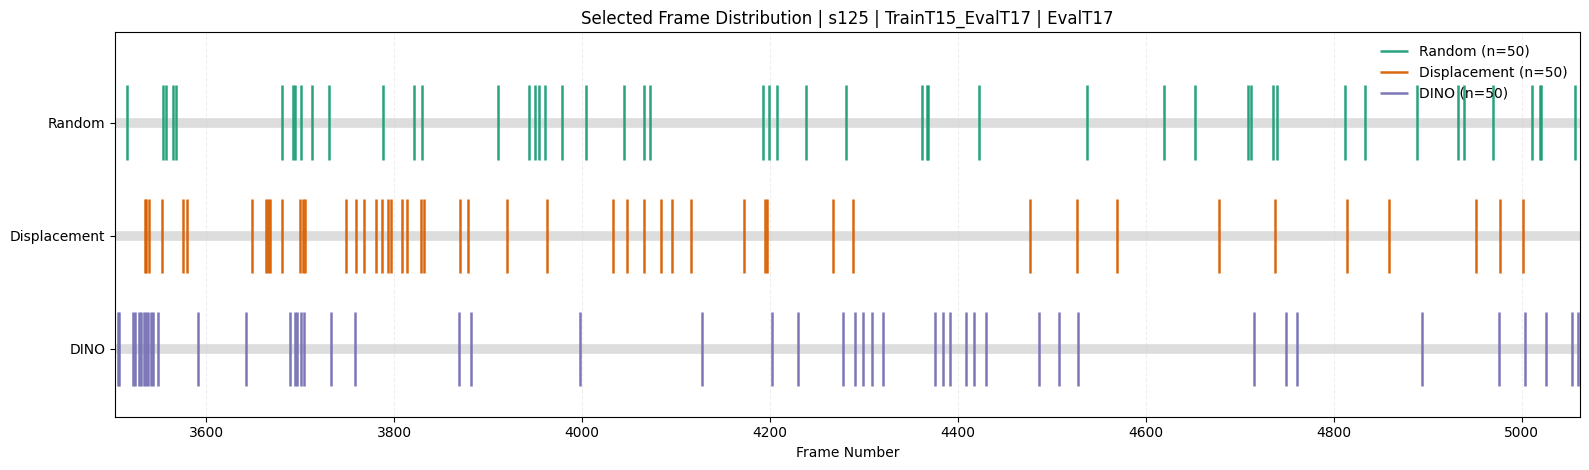


s125 / TrainT17_EvalT15
  Random: TrainT17_EvalT15_n400_s125-RandomSamplesPred.csv
  Displacement: TrainT17_EvalT15_n400_s125-DisplacementSamplesPred.csv
  DINO: TrainT17_EvalT15_n400_s125-DinoSamplesPred.csv


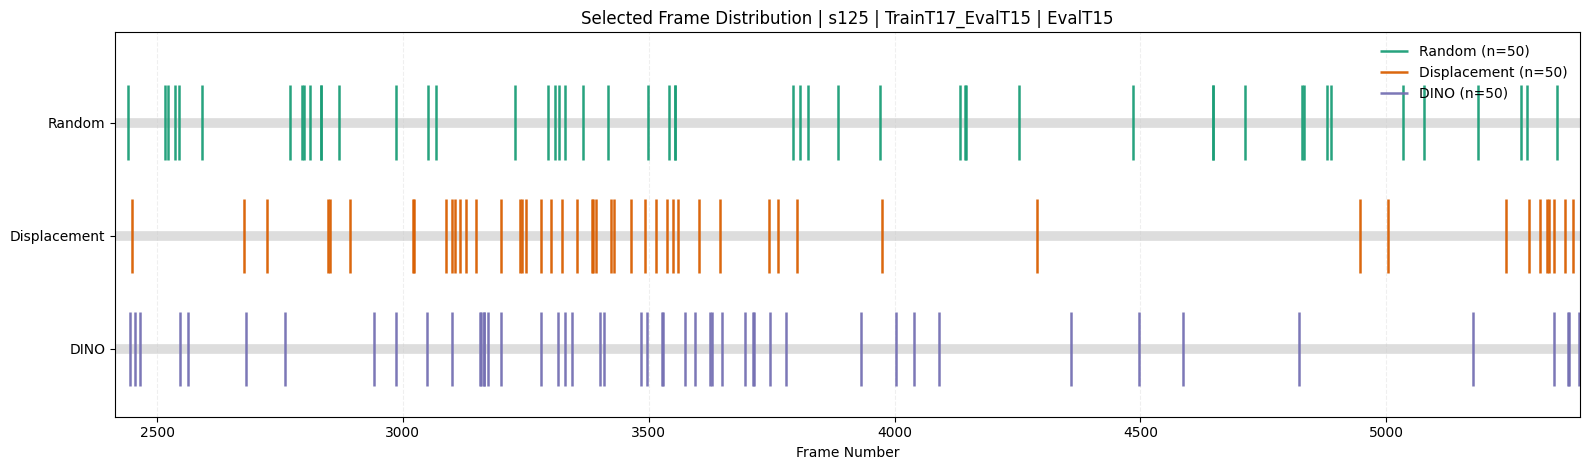

In [72]:
# Visualization 1 from exported sample CSVs (no snapshot folder; snapshot encoded in CSV name)
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SAMPLES_ROOT = Path(
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\SamplesForModelUpdate"
)

# Snapshot token expected in CSV filename, e.g. ..._s125-DinoSamplesPred.csv
SNAPSHOT = 125

# Truth frame counts used for full timeline length.
TRUTH_PATHS = {
    15: Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\TrainingData_T15\LabeledBodyPartsCoordinates.csv"),
    17: Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\TrainingData_T17\LabeledBodyPartsCoordinates.csv"),
}

METHOD_CFG = {
    "Random": {
        "dir": "RandomSamplesData",
        "suffix": "-RandomSamplesPred.csv",
        "color": "#1b9e77",
    },
    "Displacement": {
        "dir": "DisplacementSamplesData",
        "suffix": "-DisplacementSamplesPred.csv",
        "color": "#d95f02",
    },
    "DINO": {
        "dir": "DinoSamplesData",
        "suffix": "-DinoSamplesPred.csv",
        "color": "#7570b3",
    },
}

def _frame_numbers_from_sample_csv(csv_path: Path) -> np.ndarray:
    df = pd.read_csv(csv_path)
    if "image_path" not in df.columns:
        # Fallback: if no image_path, use row positions as 1-based labels.
        return np.arange(1, len(df) + 1, dtype=int)

    frame_nums = []
    # Support labels like Cam1_Img00xxxx.jpg (use xxxx as frame index) and dotted .xxxx.ext forms.
    pattern_00xxxx = re.compile(r"00(\d{4})(?!\d)", flags=re.IGNORECASE)
    pattern_dotted = re.compile(r"\.(\d{4})\.(?:jpg|jpeg|png|tif|tiff)$", flags=re.IGNORECASE)
    for p in df["image_path"].astype(str):
        stem = Path(p).stem
        m = pattern_00xxxx.search(stem)
        if not m:
            m = pattern_dotted.search(p)
        if m:
            frame_nums.append(int(m.group(1)))

    if not frame_nums:
        return np.array([], dtype=int)
    return np.sort(np.unique(np.asarray(frame_nums, dtype=int)))


def _snapshot_token_from_name(name: str):
    m = re.search(r"_s(\d+)-", str(name), flags=re.IGNORECASE)
    return int(m.group(1)) if m else None


def _discover_csvs_for_snapshot(snapshot: int):
    # Returns: {method: {train_eval_folder: csv_path}}
    out = {}
    snapshot = int(snapshot)

    for method, cfg in METHOD_CFG.items():
        base = SAMPLES_ROOT / cfg["dir"]
        per_train_eval = {}

        if base.exists():
            for train_eval_dir in sorted([p for p in base.iterdir() if p.is_dir() and p.name.startswith("TrainT")]):
                candidates = sorted(train_eval_dir.glob(f"*{cfg['suffix']}"))
                candidates = [p for p in candidates if _snapshot_token_from_name(p.name) == snapshot]
                if candidates:
                    per_train_eval[train_eval_dir.name] = candidates[0]

        out[method] = per_train_eval

    return out


def _eval_trial_from_train_eval_name(name: str):
    m = re.search(r"EvalT(\d+)", str(name), flags=re.IGNORECASE)
    return int(m.group(1)) if m else None


def _frame_num_from_image_label(path_or_name: str):
    s = str(path_or_name)
    stem = Path(s).stem
    m = re.search(r"00(\d{4})(?!\d)", stem, flags=re.IGNORECASE)
    if not m:
        m = re.search(r"\.(\d{4})\.(?:jpg|jpeg|png|tif|tiff)$", s, flags=re.IGNORECASE)
    if not m:
        m = re.search(r"(\d{4})(?!\d)", stem)
    return int(m.group(1)) if m else None


def _image_folder_bounds_from_csv(csv_path: Path):
    try:
        df = pd.read_csv(csv_path, usecols=["image_path"])
    except Exception:
        df = pd.read_csv(csv_path)
        if "image_path" not in df.columns:
            return None

    image_series = df.get("image_path", pd.Series(dtype=object)).astype(str)
    first_path = next((p for p in image_series if p and p.lower() != "nan"), None)
    if not first_path:
        return None

    folder = Path(first_path).parent
    if not folder.exists():
        return None

    files = []
    for ext in ("*.jpg", "*.jpeg", "*.png", "*.tif", "*.tiff"):
        files.extend(folder.glob(ext))

    nums = []
    for p in files:
        n = _frame_num_from_image_label(p.name)
        if n is not None:
            nums.append(int(n))

    if not nums:
        return None
    return int(min(nums)), int(max(nums))


def _axis_bounds_for_train_eval(train_eval: str, method_csvs: dict, default_min: int, default_max: int):
    for method_name in METHOD_CFG.keys():
        csv_path = method_csvs.get(method_name, {}).get(train_eval)
        if csv_path is None:
            continue
        bounds = _image_folder_bounds_from_csv(csv_path)
        if bounds is not None:
            return bounds
    return int(default_min), int(default_max)


method_csvs = _discover_csvs_for_snapshot(SNAPSHOT)

# Plot each train/eval folder found in any method for this snapshot.
all_train_eval = sorted(set().union(*[set(v.keys()) for v in method_csvs.values()]))

if not all_train_eval:
    print(f"No sample CSVs found for s{SNAPSHOT} under method folders in: {SAMPLES_ROOT}")
else:
    for train_eval in all_train_eval:
        eval_trial = _eval_trial_from_train_eval_name(train_eval)
        if eval_trial not in TRUTH_PATHS:
            print(f"Skipping {train_eval}: cannot determine Eval trial.")
            continue

        truth_df = pd.read_csv(TRUTH_PATHS[eval_trial])
        total_frames = int(len(truth_df))
        xmin, xmax = _axis_bounds_for_train_eval(train_eval, method_csvs, 1, max(total_frames, 1))

        frame_sets = {}
        labels_for_print = []
        for method, cfg in METHOD_CFG.items():
            csv_path = method_csvs.get(method, {}).get(train_eval)
            if csv_path is None:
                frame_sets[method] = np.array([], dtype=int)
                labels_for_print.append(f"{method}: MISSING")
                continue
            frame_sets[method] = _frame_numbers_from_sample_csv(csv_path)
            labels_for_print.append(f"{method}: {csv_path.name}")

        fig, ax = plt.subplots(figsize=(16, 4.8))
        methods = list(METHOD_CFG.keys())
        y_positions = np.arange(len(methods), 0, -1)

        for method, y in zip(methods, y_positions):
            ax.hlines(y=y, xmin=xmin, xmax=xmax, color="#c7c7c7", linewidth=7, alpha=0.6)
            selected = frame_sets[method]
            if selected.size > 0:
                ax.vlines(
                    selected,
                    y - 0.33,
                    y + 0.33,
                    color=METHOD_CFG[method]["color"],
                    linewidth=1.8,
                    alpha=0.95,
                    label=f"{method} (n={selected.size})",
                )

        ax.set_xlim(xmin, max(xmax, xmin + 1))
        ax.set_ylim(0.4, len(methods) + 0.8)
        ax.set_yticks(y_positions)
        ax.set_yticklabels(methods)
        ax.set_xlabel("Frame Number")
        ax.set_title(f"Selected Frame Distribution | s{SNAPSHOT} | {train_eval} | EvalT{eval_trial}")
        ax.grid(axis="x", alpha=0.2, linestyle="--")

        handles, labels = ax.get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        if by_label:
            ax.legend(by_label.values(), by_label.keys(), loc="upper right", frameon=False)

        print(f"\ns{SNAPSHOT} / {train_eval}")
        for line in labels_for_print:
            print(" ", line)

        plt.tight_layout()
        plt.show()


Summary for s125:
  Random: n=100 | files=['TrainT15_EvalT17_n400_s125-RandomSamplesPred.csv', 'TrainT17_EvalT15_n400_s125-RandomSamplesPred.csv']
  Displacement: n=100 | files=['TrainT15_EvalT17_n400_s125-DisplacementSamplesPred.csv', 'TrainT17_EvalT15_n400_s125-DisplacementSamplesPred.csv']
  DINO: n=100 | files=['TrainT15_EvalT17_n400_s125-DinoSamplesPred.csv', 'TrainT17_EvalT15_n400_s125-DinoSamplesPred.csv']


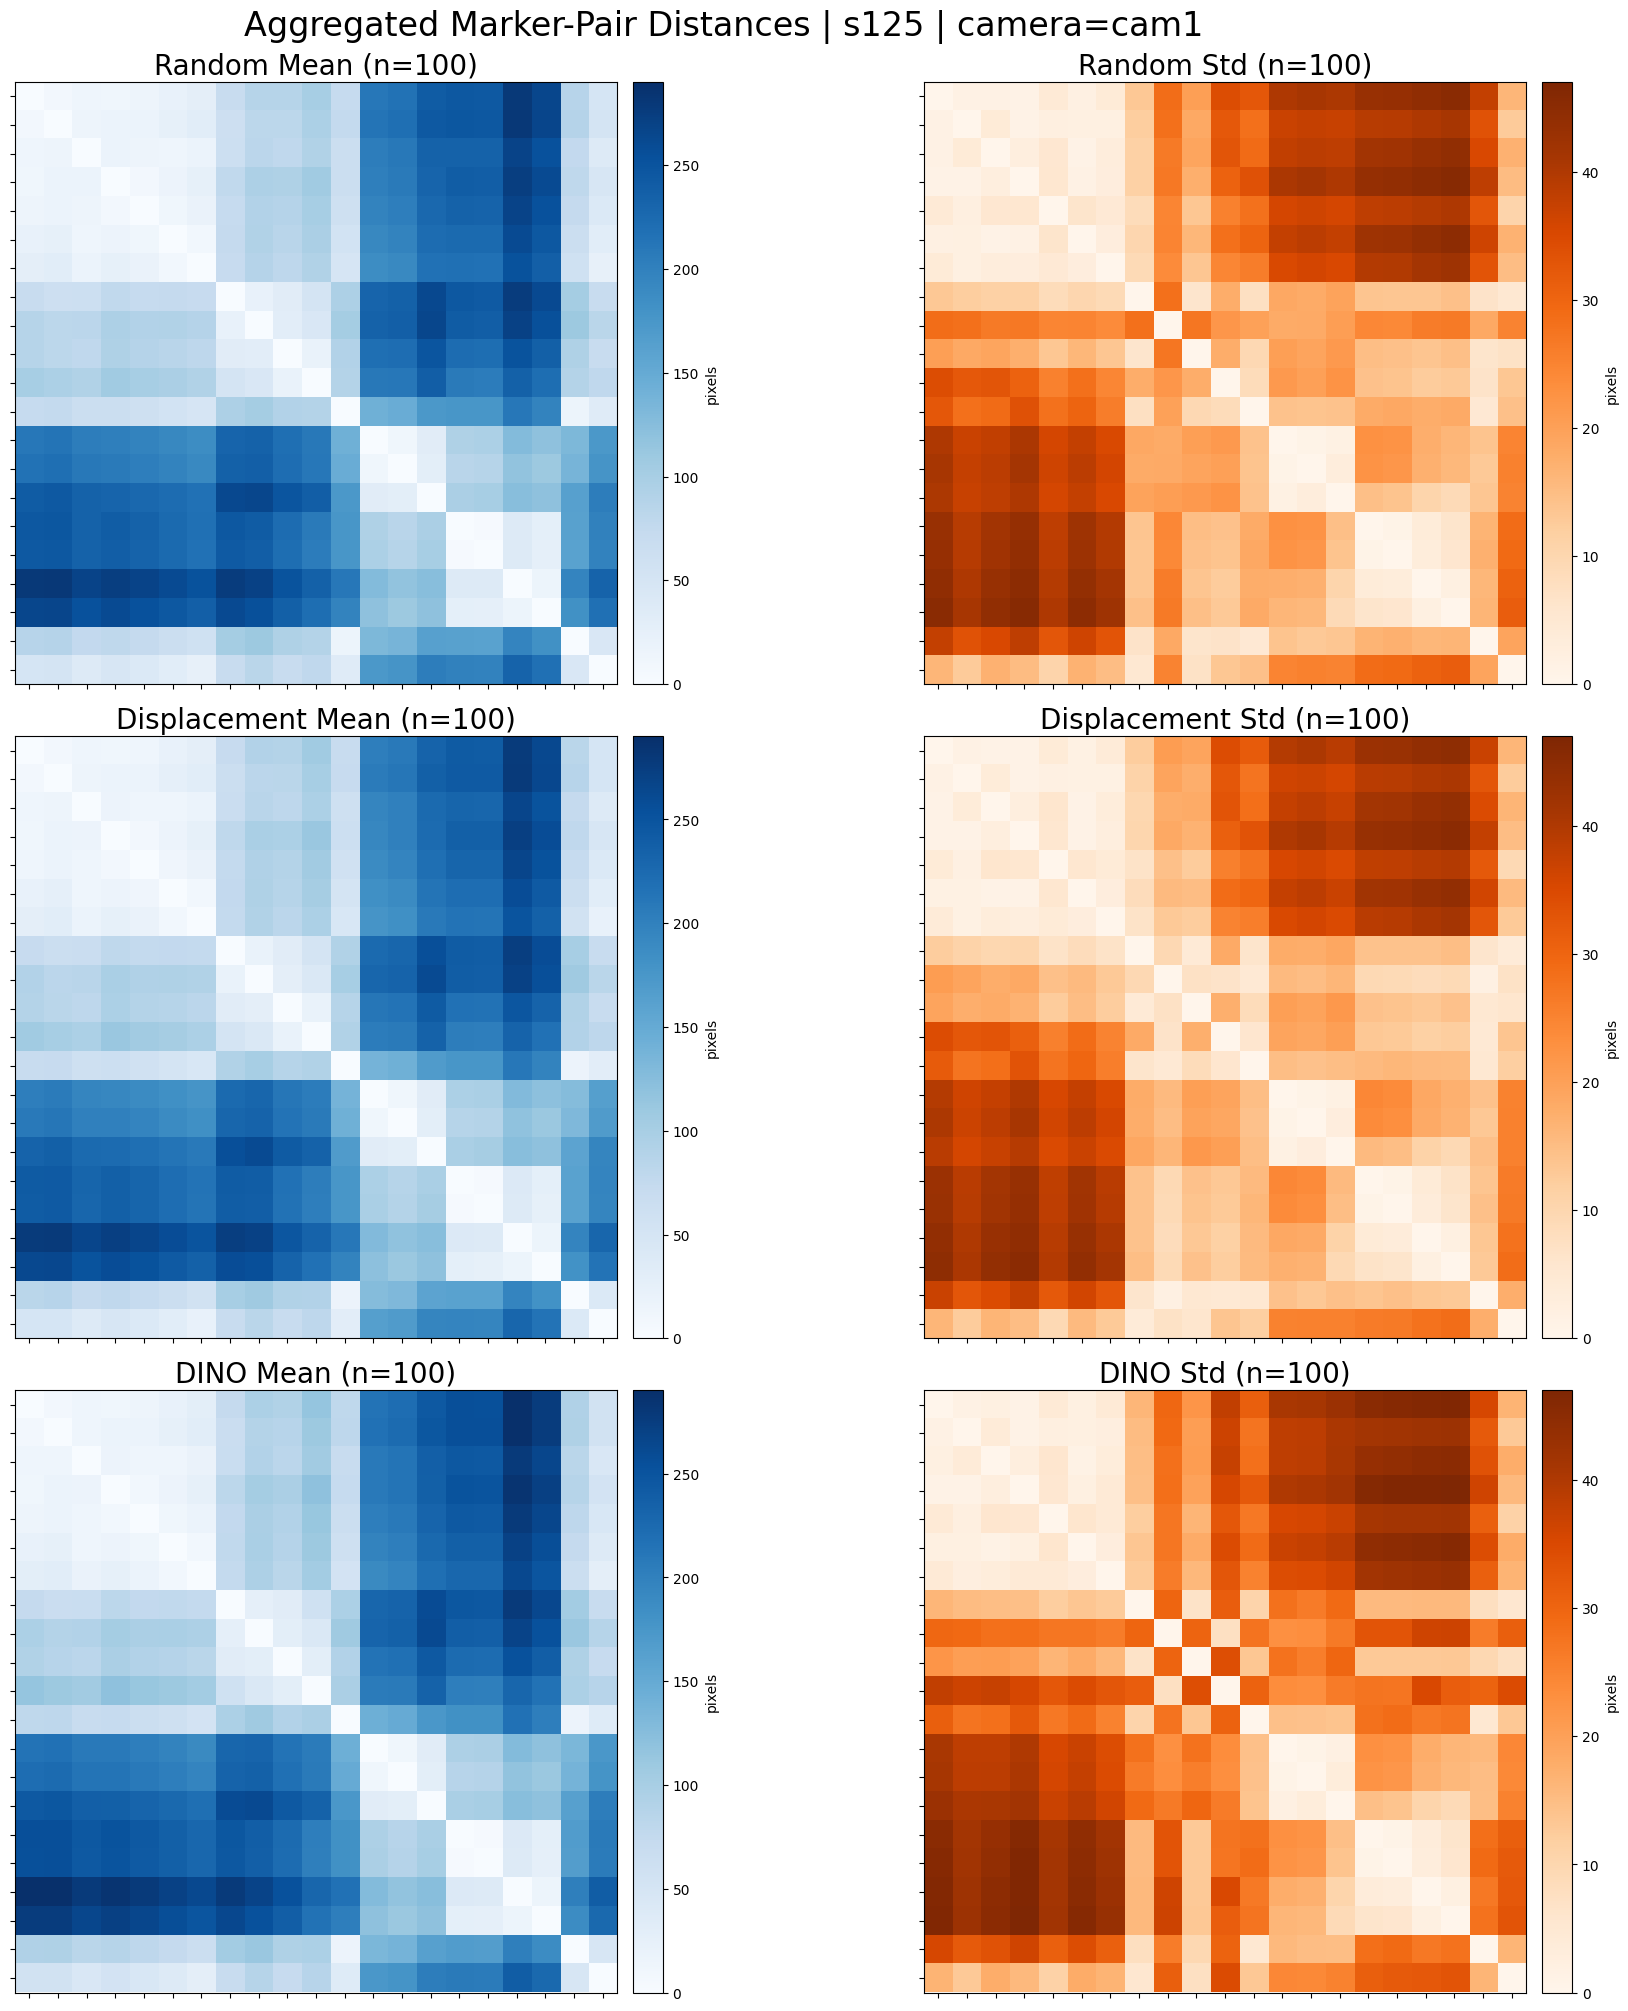

In [77]:
# Visualization 3 (3x2): rows=metric, cols=(Mean, Std), for one snapshot

import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SAMPLES_ROOT = Path(
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\SamplesForModelUpdate"
)

METHOD_CFG = {
    "Random": {
        "dir": "RandomSamplesData",
        "suffix": "-RandomSamplesPred.csv",
        "cmap_mean": "Blues",
        "cmap_std": "Oranges",
    },
    "Displacement": {
        "dir": "DisplacementSamplesData",
        "suffix": "-DisplacementSamplesPred.csv",
        "cmap_mean": "Blues",
        "cmap_std": "Oranges",
    },
    "DINO": {
        "dir": "DinoSamplesData",
        "suffix": "-DinoSamplesPred.csv",
        "cmap_mean": "Blues",
        "cmap_std": "Oranges",
    },
}

METRICS = ["Random", "Displacement", "DINO"]
SNAPSHOT = 125
TRAIN_EVALS = ["TrainT15_EvalT17", "TrainT17_EvalT15"]


def _snapshot_token_from_name(name: str):
    m = re.search(r"_s(\d+)-", str(name), flags=re.IGNORECASE)
    return int(m.group(1)) if m else None


def _find_csv(method: str, snapshot: int, train_eval: str):
    cfg = METHOD_CFG[method]
    folder = SAMPLES_ROOT / cfg["dir"] / train_eval
    if not folder.exists():
        return None

    matches = sorted(folder.glob(f"*{cfg['suffix']}"))
    matches = [p for p in matches if _snapshot_token_from_name(p.name) == int(snapshot)]
    return matches[0] if matches else None


def _load_combined_df(method: str, snapshot: int):
    frames = []
    found = []
    for te in TRAIN_EVALS:
        csv_path = _find_csv(method, snapshot, te)
        if csv_path is not None:
            d = pd.read_csv(csv_path).copy()
            d["_source_train_eval"] = te
            frames.append(d)
            found.append(csv_path.name)
    if not frames:
        return None, found
    return pd.concat(frames, axis=0, ignore_index=True), found


def _marker_pairs(df: pd.DataFrame, camera: str = "cam1"):
    pat_x = re.compile(rf"(.+?)_{camera}_X$")
    pat_y = re.compile(rf"(.+?)_{camera}_Y$")
    x_map, y_map = {}, {}

    for c in df.columns:
        cs = str(c)
        mx = pat_x.match(cs)
        my = pat_y.match(cs)
        if mx:
            x_map[mx.group(1)] = cs
        if my:
            y_map[my.group(1)] = cs

    markers = sorted(set(x_map).intersection(y_map))
    return [(m, x_map[m], y_map[m]) for m in markers]


def _distance_cube(df: pd.DataFrame, pairs):
    n_frames = len(df)
    n_markers = len(pairs)
    cube = np.full((n_frames, n_markers, n_markers), np.nan, dtype=float)

    for fi in range(n_frames):
        row = df.iloc[fi]
        coords = np.full((n_markers, 2), np.nan, dtype=float)

        for mi, (_, x_col, y_col) in enumerate(pairs):
            x = pd.to_numeric(row.get(x_col, np.nan), errors="coerce")
            y = pd.to_numeric(row.get(y_col, np.nan), errors="coerce")
            if np.isfinite(x) and np.isfinite(y):
                coords[mi, 0] = float(x)
                coords[mi, 1] = float(y)

        valid = np.isfinite(coords[:, 0]) & np.isfinite(coords[:, 1])
        if not np.any(valid):
            continue

        diff = coords[:, None, :] - coords[None, :, :]
        dist = np.sqrt(np.sum(diff * diff, axis=2))
        valid_pair = valid[:, None] & valid[None, :]
        dist[~valid_pair] = np.nan
        cube[fi] = dist

    return cube


def _aggregate_mean_std(df: pd.DataFrame, camera: str = "cam1"):
    pairs = _marker_pairs(df, camera=camera)
    if not pairs:
        return None, None, []

    cube = _distance_cube(df, pairs)
    mean_m = np.nanmean(cube, axis=0)
    std_m = np.nanstd(cube, axis=0)
    labels = [p[0] for p in pairs]
    return mean_m, std_m, labels


def _plot_3x2(snapshot: int = 125, camera: str = "cam1"):
    # collect all data first so each column uses consistent color scale
    metric_data = {}
    all_mean_max = []
    all_std_max = []

    for method in METRICS:
        df, found_files = _load_combined_df(method, snapshot)
        if df is None or len(df) == 0:
            metric_data[method] = {"ok": False, "reason": "No CSVs found", "files": found_files}
            continue

        mean_m, std_m, labels = _aggregate_mean_std(df, camera=camera)
        if mean_m is None:
            metric_data[method] = {"ok": False, "reason": f"No {camera} marker columns", "files": found_files}
            continue

        all_mean_max.append(float(np.nanmax(mean_m)) if np.isfinite(np.nanmax(mean_m)) else 0.0)
        all_std_max.append(float(np.nanmax(std_m)) if np.isfinite(np.nanmax(std_m)) else 0.0)

        metric_data[method] = {
            "ok": True,
            "mean": mean_m,
            "std": std_m,
            "labels": labels,
            "n_frames": len(df),
            "files": found_files,
        }

    mean_vmax = max(all_mean_max) if all_mean_max else 1.0
    std_vmax = max(all_std_max) if all_std_max else 1.0
    if mean_vmax <= 0:
        mean_vmax = 1.0
    if std_vmax <= 0:
        std_vmax = 1.0

    fig, axes = plt.subplots(3, 2, figsize=(18, 20), constrained_layout=True)
    fig.suptitle(f"Aggregated Marker-Pair Distances | s{snapshot} | camera={camera}", fontsize=24)

    for r, method in enumerate(METRICS):
        cfg = METHOD_CFG[method]
        d = metric_data[method]

        ax_mean = axes[r, 0]
        ax_std = axes[r, 1]

        if not d["ok"]:
            ax_mean.text(0.5, 0.5, d["reason"], ha="center", va="center")
            ax_std.text(0.5, 0.5, d["reason"], ha="center", va="center")
            ax_mean.set_title(f"{method} Mean")
            ax_std.set_title(f"{method} Std")
            ax_mean.set_axis_off()
            ax_std.set_axis_off()
            continue

        im_mean = ax_mean.imshow(d["mean"], cmap=cfg["cmap_mean"], vmin=0.0, vmax=mean_vmax)
        ax_mean.set_title(f"{method} Mean (n={d['n_frames']})", size=20)
        ax_mean.set_xticks(range(len(d["labels"])))
        ax_mean.set_yticks(range(len(d["labels"])))
        ax_mean.set_xticklabels("", rotation=90, fontsize=6)
        ax_mean.set_yticklabels("", fontsize=6)
        cbm = fig.colorbar(im_mean, ax=ax_mean, fraction=0.046, pad=0.02)
        cbm.set_label("pixels")

        im_std = ax_std.imshow(d["std"], cmap=cfg["cmap_std"], vmin=0.0, vmax=std_vmax)
        ax_std.set_title(f"{method} Std (n={d['n_frames']})", size=20)
        ax_std.set_xticks(range(len(d["labels"])))
        ax_std.set_yticks(range(len(d["labels"])))
        ax_std.set_xticklabels("", rotation=90, fontsize=6)
        ax_std.set_yticklabels("", fontsize=6)
        cbs = fig.colorbar(im_std, ax=ax_std, fraction=0.046, pad=0.02)
        cbs.set_label("pixels")

    print(f"\nSummary for s{snapshot}:")
    for method in METRICS:
        d = metric_data[method]
        if d["ok"]:
            print(f"  {method}: n={d['n_frames']} | files={d['files']}")
        else:
            print(f"  {method}: {d['reason']} | files={d.get('files', [])}")

    plt.show()


_plot_3x2(snapshot=SNAPSHOT, camera="cam1")

In [78]:
# Lets get the corresponding truth values for the selected frames 
# we have the truth datasets for both trials, so we can match based on the Eval trial in the folder name.
def _load_truth_for_eval_trial(eval_trial: int):
    path = TRUTH_PATHS.get(eval_trial)
    if path is None or not path.exists():
        print(f"No truth CSV found for Eval trial {eval_trial}")
        return None
    return pd.read_csv(path)
print([_load_truth_for_eval_trial(eval) for eval in [15, 17]])

# Now we must subset the truth dataframes to only the selected frames for each method, and then we can compute some error metrics (like mean distance error) against the predicted points in the sample CSVs. This will allow us to compare how well the different selection methods are doing in terms of picking frames that have high or low error compared to the ground truth.



[      Cranium_Left_Anterior_cam1_X  Cranium_Left_Anterior_cam1_Y  \
0                       374.051042                    177.387317   
1                       373.994566                    177.312765   
2                       373.919796                    177.280367   
3                       374.051652                    177.362585   
4                       374.062160                    177.449801   
...                            ...                           ...   
2975                    361.500000                    160.000000   
2976                    361.500000                    160.000000   
2977                    361.500000                    160.000000   
2978                    361.500000                    160.000000   
2979                    361.500000                    160.000000   

      Cranium_Left_Anterior_cam2_X  Cranium_Left_Anterior_cam2_Y  \
0                       254.926150                    192.048370   
1                       254.770071            

[WindowsPath('C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/DeepLabCut2/DavidBowie/SamplesForModelUpdate/RandomSamplesData/TrainT15_EvalT17/TrainT15_EvalT17_n400_s125-RandomSamplesPred.csv'), WindowsPath('C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/DeepLabCut2/DavidBowie/SamplesForModelUpdate/RandomSamplesData/TrainT15_EvalT17/TrainT15_EvalT17_n800_s125-RandomSamplesPred.csv')]
Evaluating Random | s125 | TrainT15_EvalT17 | TrainT15_EvalT17_n400_s125-RandomSamplesPred.csv
Evaluating Random | s125 | TrainT15_EvalT17 | TrainT15_EvalT17_n800_s125-RandomSamplesPred.csv
[WindowsPath('C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/DeepLabCut2/DavidBowie/SamplesForModelUpdate/RandomSamplesData/TrainT17_EvalT15/TrainT17_EvalT15_n400_s125-RandomSamplesPred.csv'), WindowsPath('C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/DeepLabCut2/DavidBowie/SamplesForModelUpdate/RandomSamplesData/T

,method,snapshot,train_eval,model_build,status,numframes,csv,truth_subset_csv,per_frame_errors_csv,frame_index_map_csv,n_frames_evaluated,n_index_explicit,n_index_basename,n_index_frame_to_folder,n_index_fallback,mean_err_cam1,mean_err_cam2,mean_err_all,median_err_all,std_err_all
0,Random,125,TrainT15_EvalT17,TrainT15_EvalT17|s125,ok,400,TrainT15_EvalT17_n400_s125-RandomSamplesPred.csv,TrainT15_EvalT17_n400_s125-TruthSubset.csv,TrainT15_EvalT17_n400_s125-PerFrameErrors.csv,TrainT15_EvalT17_n400_s125-FrameIndexMap.csv,50,0,50,0,0,2.636548,2.590010,2.613279,2.004138,4.807133
1,Random,125,TrainT15_EvalT17,TrainT15_EvalT17|s125,ok,800,TrainT15_EvalT17_n800_s125-RandomSamplesPred.csv,TrainT15_EvalT17_n800_s125-TruthSubset.csv,TrainT15_EvalT17_n800_s125-PerFrameErrors.csv,TrainT15_EvalT17_n800_s125-FrameIndexMap.csv,50,0,50,0,0,2.249736,3.285643,2.767689,2.053489,4.054429
4,Random,150,TrainT15_EvalT17,TrainT15_EvalT17|s150,ok,400,TrainT15_EvalT17_n400_s150-RandomSamplesPred.csv,TrainT15_EvalT17_n400_s150-TruthSubset.csv,TrainT15_EvalT17_n400_s150-PerFrameErrors.csv,TrainT15_EvalT17_n400_s150-FrameIndexMap.csv,50,0,50,0,0,2.637596,2.560119,2.598858,1.991188,4.798786
5,Random,150,TrainT15_EvalT17,TrainT15_EvalT17|s150,ok,800,TrainT15_EvalT17_n800_s150-RandomSamplesPred.csv,TrainT15_EvalT17_n800_s150-TruthSubset.csv,TrainT15_EvalT17_n800_s150-PerFrameErrors.csv,TrainT15_EvalT17_n800_s150-FrameIndexMap.csv,50,0,50,0,0,2.152120,3.998858,3.075489,2.070857,4.226349
2,Random,125,TrainT17_EvalT15,TrainT17_EvalT15|s125,ok,400,TrainT17_EvalT15_n400_s125-RandomSamplesPred.csv,TrainT17_EvalT15_n400_s125-TruthSubset.csv,TrainT17_EvalT15_n400_s125-PerFrameErrors.csv,TrainT17_EvalT15_n400_s125-FrameIndexMap.csv,50,0,50,0,0,3.407486,3.284240,3.345863,2.934278,1.643206
3,Random,125,TrainT17_EvalT15,TrainT17_EvalT15|s125,ok,800,TrainT17_EvalT15_n800_s125-RandomSamplesPred.csv,TrainT17_EvalT15_n800_s125-TruthSubset.csv,TrainT17_EvalT15_n800_s125-PerFrameErrors.csv,TrainT17_EvalT15_n800_s125-FrameIndexMap.csv,50,0,50,0,0,3.288049,2.857680,3.072864,2.470427,1.578777
6,Random,150,TrainT17_EvalT15,TrainT17_EvalT15|s150,ok,400,TrainT17_EvalT15_n400_s150-RandomSamplesPred.csv,TrainT17_EvalT15_n400_s150-TruthSubset.csv,TrainT17_EvalT15_n400_s150-PerFrameErrors.csv,TrainT17_EvalT15_n400_s150-FrameIndexMap.csv,50,0,50,0,0,3.437272,3.309144,3.373208,2.896470,1.661385
7,Random,150,TrainT17_EvalT15,TrainT17_EvalT15|s150,ok,800,TrainT17_EvalT15_n800_s150-RandomSamplesPred.csv,TrainT17_EvalT15_n800_s150-TruthSubset.csv,TrainT17_EvalT15_n800_s150-PerFrameErrors.csv,TrainT17_EvalT15_n800_s150-FrameIndexMap.csv,50,0,50,0,0,3.346122,2.986373,3.166248,2.437823,1.639220


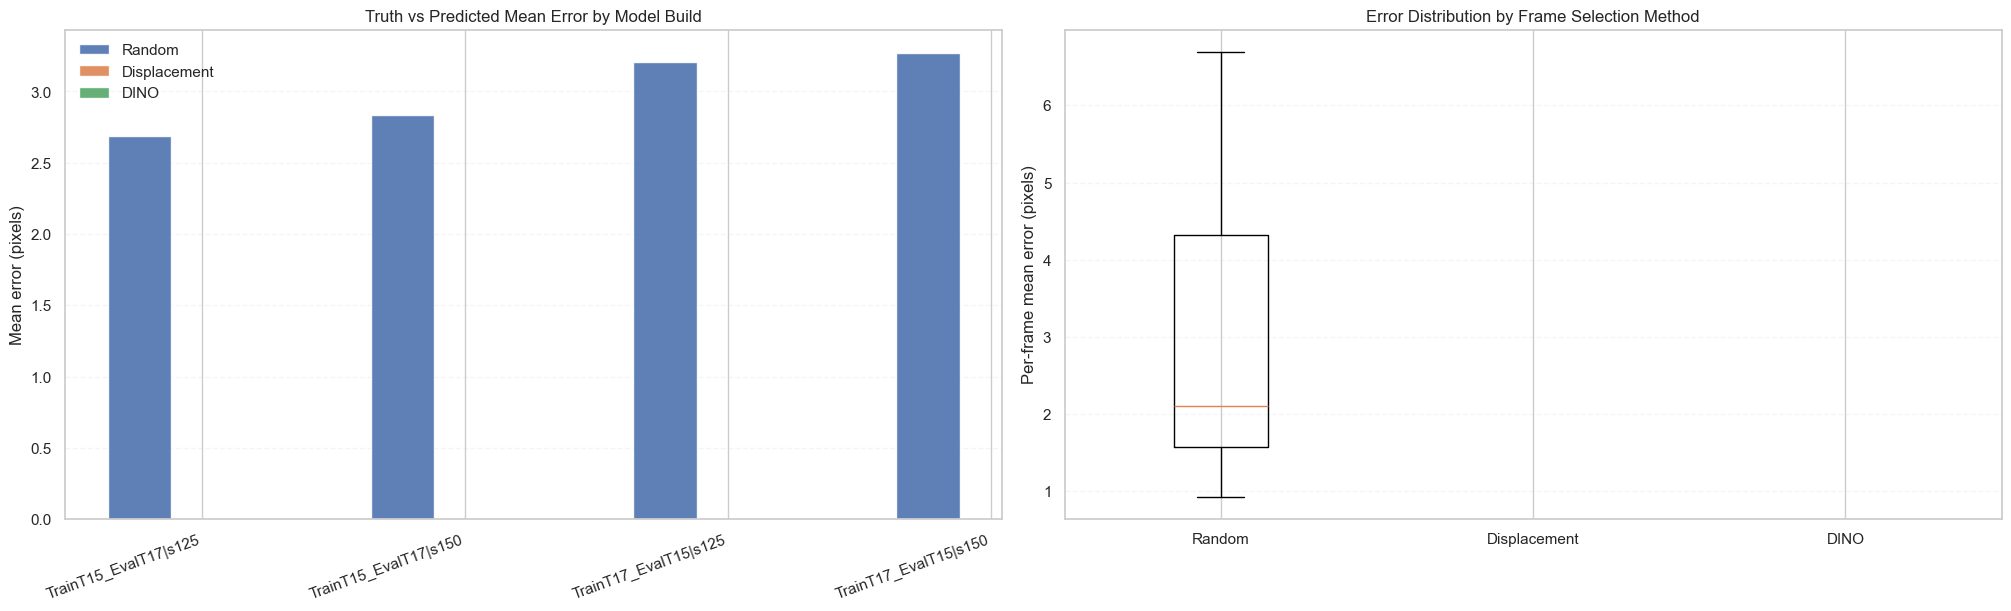


Mean error table (pixels):


model_build,TrainT15_EvalT17|s125,TrainT15_EvalT17|s150,TrainT17_EvalT15|s125,TrainT17_EvalT15|s150
method,,,,
Random,2.690484,2.837173,3.209364,3.269728
Displacement,NaN,NaN,NaN,NaN
DINO,NaN,NaN,NaN,NaN



Index alignment audit (evaluated rows):


,method,model_build,n_frames_evaluated,n_index_explicit,numframes,n_index_basename,n_index_frame_to_folder,n_index_fallback
0,Random,TrainT15_EvalT17|s125,50,0,400,50,0,0
1,Random,TrainT15_EvalT17|s125,50,0,800,50,0,0
4,Random,TrainT15_EvalT17|s150,50,0,400,50,0,0
5,Random,TrainT15_EvalT17|s150,50,0,800,50,0,0
2,Random,TrainT17_EvalT15|s125,50,0,400,50,0,0
3,Random,TrainT17_EvalT15|s125,50,0,800,50,0,0
6,Random,TrainT17_EvalT15|s150,50,0,400,50,0,0
7,Random,TrainT17_EvalT15|s150,50,0,800,50,0,0


[WindowsPath('C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/DeepLabCut2/DavidBowie/SamplesForModelUpdate/DisplacementSamplesData/TrainT15_EvalT17/TrainT15_EvalT17_n400_s125-DisplacementSamplesPred.csv'), WindowsPath('C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/DeepLabCut2/DavidBowie/SamplesForModelUpdate/DisplacementSamplesData/TrainT15_EvalT17/TrainT15_EvalT17_n800_s125-DisplacementSamplesPred.csv')]
Evaluating Displacement | s125 | TrainT15_EvalT17 | TrainT15_EvalT17_n400_s125-DisplacementSamplesPred.csv
Evaluating Displacement | s125 | TrainT15_EvalT17 | TrainT15_EvalT17_n800_s125-DisplacementSamplesPred.csv
[WindowsPath('C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/DeepLabCut2/DavidBowie/SamplesForModelUpdate/DisplacementSamplesData/TrainT17_EvalT15/TrainT17_EvalT15_n400_s125-DisplacementSamplesPred.csv'), WindowsPath('C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/Deep

,method,snapshot,train_eval,model_build,status,numframes,csv,truth_subset_csv,per_frame_errors_csv,frame_index_map_csv,n_frames_evaluated,n_index_explicit,n_index_basename,n_index_frame_to_folder,n_index_fallback,mean_err_cam1,mean_err_cam2,mean_err_all,median_err_all,std_err_all
8,Displacement,125,TrainT15_EvalT17,TrainT15_EvalT17|s125,ok,400,TrainT15_EvalT17_n400_s125-DisplacementSamples...,TrainT15_EvalT17_n400_s125-TruthSubset.csv,TrainT15_EvalT17_n400_s125-PerFrameErrors.csv,TrainT15_EvalT17_n400_s125-FrameIndexMap.csv,50,0,50,0,0,1.970407,2.872984,2.421695,2.095726,1.629436
9,Displacement,125,TrainT15_EvalT17,TrainT15_EvalT17|s125,ok,800,TrainT15_EvalT17_n800_s125-DisplacementSamples...,TrainT15_EvalT17_n800_s125-TruthSubset.csv,TrainT15_EvalT17_n800_s125-PerFrameErrors.csv,TrainT15_EvalT17_n800_s125-FrameIndexMap.csv,50,0,50,0,0,1.834131,3.444332,2.639232,2.277561,1.655114
0,Random,125,TrainT15_EvalT17,TrainT15_EvalT17|s125,ok,400,TrainT15_EvalT17_n400_s125-RandomSamplesPred.csv,TrainT15_EvalT17_n400_s125-TruthSubset.csv,TrainT15_EvalT17_n400_s125-PerFrameErrors.csv,TrainT15_EvalT17_n400_s125-FrameIndexMap.csv,50,0,50,0,0,2.636548,2.590010,2.613279,2.004138,4.807133
1,Random,125,TrainT15_EvalT17,TrainT15_EvalT17|s125,ok,800,TrainT15_EvalT17_n800_s125-RandomSamplesPred.csv,TrainT15_EvalT17_n800_s125-TruthSubset.csv,TrainT15_EvalT17_n800_s125-PerFrameErrors.csv,TrainT15_EvalT17_n800_s125-FrameIndexMap.csv,50,0,50,0,0,2.249736,3.285643,2.767689,2.053489,4.054429
12,Displacement,150,TrainT15_EvalT17,TrainT15_EvalT17|s150,ok,400,TrainT15_EvalT17_n400_s150-DisplacementSamples...,TrainT15_EvalT17_n400_s150-TruthSubset.csv,TrainT15_EvalT17_n400_s150-PerFrameErrors.csv,TrainT15_EvalT17_n400_s150-FrameIndexMap.csv,50,0,50,0,0,2.029562,2.624524,2.327043,2.139876,1.229184
13,Displacement,150,TrainT15_EvalT17,TrainT15_EvalT17|s150,ok,800,TrainT15_EvalT17_n800_s150-DisplacementSamples...,TrainT15_EvalT17_n800_s150-TruthSubset.csv,TrainT15_EvalT17_n800_s150-PerFrameErrors.csv,TrainT15_EvalT17_n800_s150-FrameIndexMap.csv,50,0,50,0,0,1.834079,3.594172,2.714126,2.366874,1.661741
4,Random,150,TrainT15_EvalT17,TrainT15_EvalT17|s150,ok,400,TrainT15_EvalT17_n400_s150-RandomSamplesPred.csv,TrainT15_EvalT17_n400_s150-TruthSubset.csv,TrainT15_EvalT17_n400_s150-PerFrameErrors.csv,TrainT15_EvalT17_n400_s150-FrameIndexMap.csv,50,0,50,0,0,2.637596,2.560119,2.598858,1.991188,4.798786
5,Random,150,TrainT15_EvalT17,TrainT15_EvalT17|s150,ok,800,TrainT15_EvalT17_n800_s150-RandomSamplesPred.csv,TrainT15_EvalT17_n800_s150-TruthSubset.csv,TrainT15_EvalT17_n800_s150-PerFrameErrors.csv,TrainT15_EvalT17_n800_s150-FrameIndexMap.csv,50,0,50,0,0,2.152120,3.998858,3.075489,2.070857,4.226349
10,Displacement,125,TrainT17_EvalT15,TrainT17_EvalT15|s125,ok,400,TrainT17_EvalT15_n400_s125-DisplacementSamples...,TrainT17_EvalT15_n400_s125-TruthSubset.csv,TrainT17_EvalT15_n400_s125-PerFrameErrors.csv,TrainT17_EvalT15_n400_s125-FrameIndexMap.csv,50,0,50,0,0,2.859604,3.160963,3.010283,2.029021,1.525557
11,Displacement,125,TrainT17_EvalT15,TrainT17_EvalT15|s125,ok,800,TrainT17_EvalT15_n800_s125-DisplacementSamples...,TrainT17_EvalT15_n800_s125-TruthSubset.csv,TrainT17_EvalT15_n800_s125-PerFrameErrors.csv,TrainT17_EvalT15_n800_s125-FrameIndexMap.csv,50,0,50,0,0,2.660626,2.955149,2.807888,1.681540,1.553095


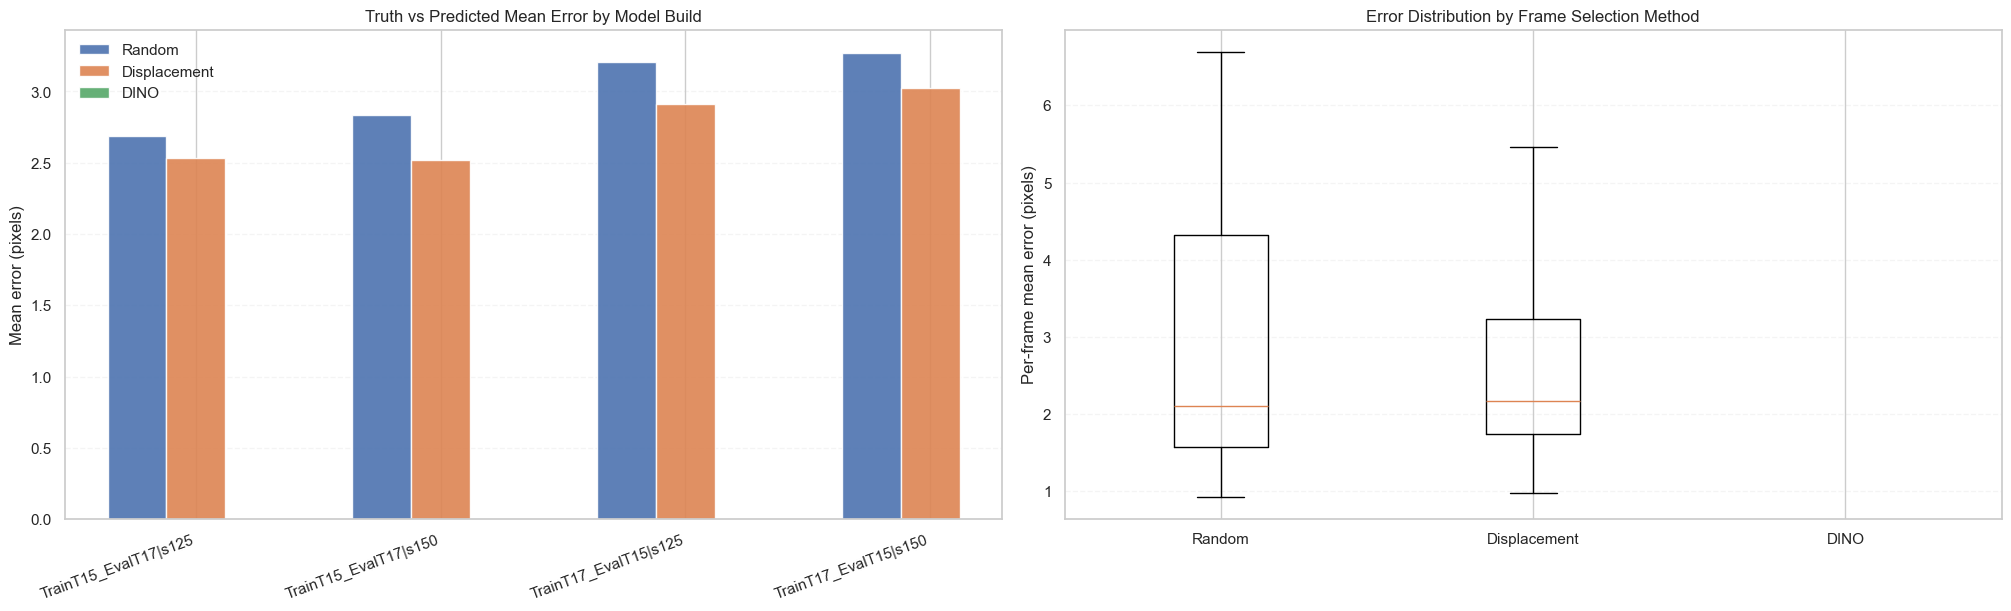


Mean error table (pixels):


model_build,TrainT15_EvalT17|s125,TrainT15_EvalT17|s150,TrainT17_EvalT15|s125,TrainT17_EvalT15|s150
method,,,,
Random,2.690484,2.837173,3.209364,3.269728
Displacement,2.530464,2.520584,2.909086,3.022968
DINO,NaN,NaN,NaN,NaN



Index alignment audit (evaluated rows):


,method,model_build,n_frames_evaluated,n_index_explicit,numframes,n_index_basename,n_index_frame_to_folder,n_index_fallback
8,Displacement,TrainT15_EvalT17|s125,50,0,400,50,0,0
9,Displacement,TrainT15_EvalT17|s125,50,0,800,50,0,0
0,Random,TrainT15_EvalT17|s125,50,0,400,50,0,0
1,Random,TrainT15_EvalT17|s125,50,0,800,50,0,0
12,Displacement,TrainT15_EvalT17|s150,50,0,400,50,0,0
13,Displacement,TrainT15_EvalT17|s150,50,0,800,50,0,0
4,Random,TrainT15_EvalT17|s150,50,0,400,50,0,0
5,Random,TrainT15_EvalT17|s150,50,0,800,50,0,0
10,Displacement,TrainT17_EvalT15|s125,50,0,400,50,0,0
11,Displacement,TrainT17_EvalT15|s125,50,0,800,50,0,0


[WindowsPath('C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/DeepLabCut2/DavidBowie/SamplesForModelUpdate/DinoSamplesData/TrainT15_EvalT17/TrainT15_EvalT17_n400_s125-DinoSamplesPred.csv'), WindowsPath('C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/DeepLabCut2/DavidBowie/SamplesForModelUpdate/DinoSamplesData/TrainT15_EvalT17/TrainT15_EvalT17_n800_s125-DinoSamplesPred.csv')]
Evaluating DINO | s125 | TrainT15_EvalT17 | TrainT15_EvalT17_n400_s125-DinoSamplesPred.csv
Evaluating DINO | s125 | TrainT15_EvalT17 | TrainT15_EvalT17_n800_s125-DinoSamplesPred.csv
[WindowsPath('C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/DeepLabCut2/DavidBowie/SamplesForModelUpdate/DinoSamplesData/TrainT17_EvalT15/TrainT17_EvalT15_n400_s125-DinoSamplesPred.csv'), WindowsPath('C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/DeepLabCut2/DavidBowie/SamplesForModelUpdate/DinoSamplesData/TrainT17_EvalT15/TrainT

,method,snapshot,train_eval,model_build,status,numframes,csv,truth_subset_csv,per_frame_errors_csv,frame_index_map_csv,n_frames_evaluated,n_index_explicit,n_index_basename,n_index_frame_to_folder,n_index_fallback,mean_err_cam1,mean_err_cam2,mean_err_all,median_err_all,std_err_all
16,DINO,125,TrainT15_EvalT17,TrainT15_EvalT17|s125,ok,400,TrainT15_EvalT17_n400_s125-DinoSamplesPred.csv,TrainT15_EvalT17_n400_s125-TruthSubset.csv,TrainT15_EvalT17_n400_s125-PerFrameErrors.csv,TrainT15_EvalT17_n400_s125-FrameIndexMap.csv,50,0,50,0,0,4.663055,5.132148,4.897602,2.061265,8.565752
17,DINO,125,TrainT15_EvalT17,TrainT15_EvalT17|s125,ok,800,TrainT15_EvalT17_n800_s125-DinoSamplesPred.csv,TrainT15_EvalT17_n800_s125-TruthSubset.csv,TrainT15_EvalT17_n800_s125-PerFrameErrors.csv,TrainT15_EvalT17_n800_s125-FrameIndexMap.csv,50,0,50,0,0,3.219394,6.400763,4.810079,2.037310,6.688870
8,Displacement,125,TrainT15_EvalT17,TrainT15_EvalT17|s125,ok,400,TrainT15_EvalT17_n400_s125-DisplacementSamples...,TrainT15_EvalT17_n400_s125-TruthSubset.csv,TrainT15_EvalT17_n400_s125-PerFrameErrors.csv,TrainT15_EvalT17_n400_s125-FrameIndexMap.csv,50,0,50,0,0,1.970407,2.872984,2.421695,2.095726,1.629436
9,Displacement,125,TrainT15_EvalT17,TrainT15_EvalT17|s125,ok,800,TrainT15_EvalT17_n800_s125-DisplacementSamples...,TrainT15_EvalT17_n800_s125-TruthSubset.csv,TrainT15_EvalT17_n800_s125-PerFrameErrors.csv,TrainT15_EvalT17_n800_s125-FrameIndexMap.csv,50,0,50,0,0,1.834131,3.444332,2.639232,2.277561,1.655114
0,Random,125,TrainT15_EvalT17,TrainT15_EvalT17|s125,ok,400,TrainT15_EvalT17_n400_s125-RandomSamplesPred.csv,TrainT15_EvalT17_n400_s125-TruthSubset.csv,TrainT15_EvalT17_n400_s125-PerFrameErrors.csv,TrainT15_EvalT17_n400_s125-FrameIndexMap.csv,50,0,50,0,0,2.636548,2.590010,2.613279,2.004138,4.807133
1,Random,125,TrainT15_EvalT17,TrainT15_EvalT17|s125,ok,800,TrainT15_EvalT17_n800_s125-RandomSamplesPred.csv,TrainT15_EvalT17_n800_s125-TruthSubset.csv,TrainT15_EvalT17_n800_s125-PerFrameErrors.csv,TrainT15_EvalT17_n800_s125-FrameIndexMap.csv,50,0,50,0,0,2.249736,3.285643,2.767689,2.053489,4.054429
20,DINO,150,TrainT15_EvalT17,TrainT15_EvalT17|s150,ok,400,TrainT15_EvalT17_n400_s150-DinoSamplesPred.csv,TrainT15_EvalT17_n400_s150-TruthSubset.csv,TrainT15_EvalT17_n400_s150-PerFrameErrors.csv,TrainT15_EvalT17_n400_s150-FrameIndexMap.csv,50,0,50,0,0,4.919194,5.185625,5.052410,2.125634,8.824409
21,DINO,150,TrainT15_EvalT17,TrainT15_EvalT17|s150,ok,800,TrainT15_EvalT17_n800_s150-DinoSamplesPred.csv,TrainT15_EvalT17_n800_s150-TruthSubset.csv,TrainT15_EvalT17_n800_s150-PerFrameErrors.csv,TrainT15_EvalT17_n800_s150-FrameIndexMap.csv,50,0,50,0,0,3.183038,6.814923,4.998981,2.074585,6.681182
12,Displacement,150,TrainT15_EvalT17,TrainT15_EvalT17|s150,ok,400,TrainT15_EvalT17_n400_s150-DisplacementSamples...,TrainT15_EvalT17_n400_s150-TruthSubset.csv,TrainT15_EvalT17_n400_s150-PerFrameErrors.csv,TrainT15_EvalT17_n400_s150-FrameIndexMap.csv,50,0,50,0,0,2.029562,2.624524,2.327043,2.139876,1.229184
13,Displacement,150,TrainT15_EvalT17,TrainT15_EvalT17|s150,ok,800,TrainT15_EvalT17_n800_s150-DisplacementSamples...,TrainT15_EvalT17_n800_s150-TruthSubset.csv,TrainT15_EvalT17_n800_s150-PerFrameErrors.csv,TrainT15_EvalT17_n800_s150-FrameIndexMap.csv,50,0,50,0,0,1.834079,3.594172,2.714126,2.366874,1.661741


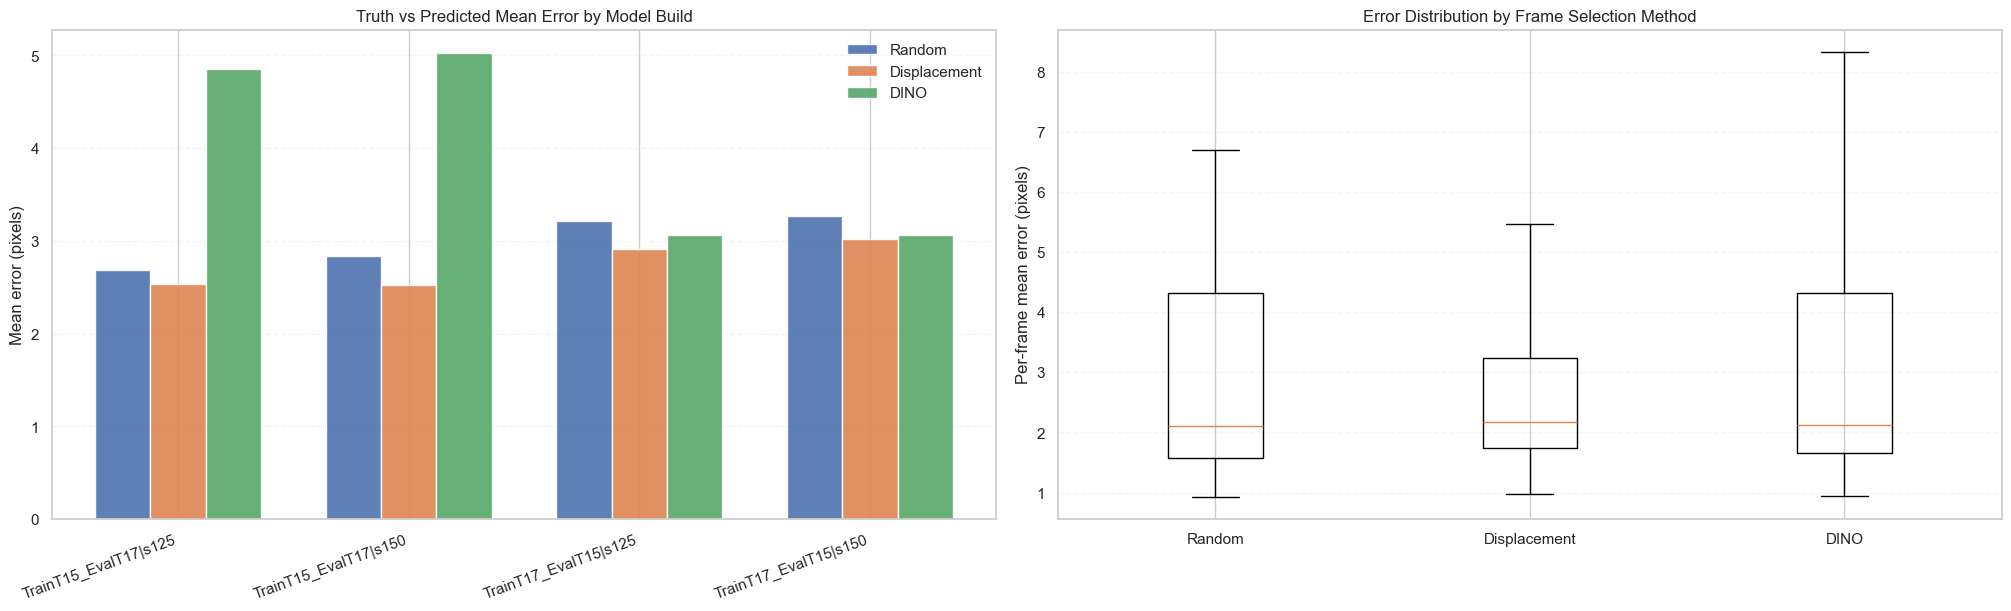


Mean error table (pixels):


model_build,TrainT15_EvalT17|s125,TrainT15_EvalT17|s150,TrainT17_EvalT15|s125,TrainT17_EvalT15|s150
method,,,,
Random,2.690484,2.837173,3.209364,3.269728
Displacement,2.530464,2.520584,2.909086,3.022968
DINO,4.853840,5.025695,3.059637,3.059409



Index alignment audit (evaluated rows):


,method,model_build,n_frames_evaluated,n_index_explicit,numframes,n_index_basename,n_index_frame_to_folder,n_index_fallback
16,DINO,TrainT15_EvalT17|s125,50,0,400,50,0,0
17,DINO,TrainT15_EvalT17|s125,50,0,800,50,0,0
8,Displacement,TrainT15_EvalT17|s125,50,0,400,50,0,0
9,Displacement,TrainT15_EvalT17|s125,50,0,800,50,0,0
0,Random,TrainT15_EvalT17|s125,50,0,400,50,0,0
1,Random,TrainT15_EvalT17|s125,50,0,800,50,0,0
20,DINO,TrainT15_EvalT17|s150,50,0,400,50,0,0
21,DINO,TrainT15_EvalT17|s150,50,0,800,50,0,0
12,Displacement,TrainT15_EvalT17|s150,50,0,400,50,0,0
13,Displacement,TrainT15_EvalT17|s150,50,0,800,50,0,0


In [92]:
# Compare truth vs predicted across model builds and frame-selection methods.
# Align truth by selected-frame index derived from selected image paths, with explicit index backfill exports.

import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SAMPLES_ROOT = Path(
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\SamplesForModelUpdate"
)

METHOD_CFG = {
    "Random": {
        "dir": "RandomSamplesData",
        "suffix": "-RandomSamplesPred.csv",
    },
    "Displacement": {
        "dir": "DisplacementSamplesData",
        "suffix": "-DisplacementSamplesPred.csv",
    },
    "DINO": {
        "dir": "DinoSamplesData",
        "suffix": "-DinoSamplesPred.csv",
    },
}

SNAPSHOTS = [125, 150]
TRAIN_EVALS = ["TrainT15_EvalT17", "TrainT17_EvalT15"]

TRUTH_PATHS = {
    15: Path(
        r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\TrainingData_T15\LabeledBodyPartsCoordinates.csv"
    ),
    17: Path(
        r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\TrainingData_T17\LabeledBodyPartsCoordinates.csv"
    ),
}


def _snapshot_token_from_name(name: str):
    m = re.search(r"_s(\d+)-", str(name), flags=re.IGNORECASE)
    return int(m.group(1)) if m else None


def _parse_eval_trial(train_eval: str):
    m = re.search(r"EvalT?(\d+)", str(train_eval), flags=re.IGNORECASE)
    return int(m.group(1)) if m else None


def _find_sample_csv(method: str, snapshot: int, train_eval: str):
    cfg = METHOD_CFG[method]
    folder = SAMPLES_ROOT / cfg["dir"] / train_eval
    if not folder.exists():
        return None

    matches = sorted(folder.glob(f"*{cfg['suffix']}"))
    matches = [p for p in matches if _snapshot_token_from_name(p.name) == int(snapshot)]
    return matches if matches else None


def _extract_frame_num(image_path: str):
    if not isinstance(image_path, str):
        return None

    stem = Path(image_path).stem

    # Preferred parsing for labels like Cam1_Img003516 -> frame 3516
    m = re.search(r"00(\d{4})(?!\d)", stem, flags=re.IGNORECASE)
    if m:
        return int(m.group(1))

    # Fallback for names like *.3516.jpg
    m = re.search(r"\.(\d{4})\.(?:jpg|jpeg|png|tif|tiff)$", image_path, flags=re.IGNORECASE)
    if m:
        return int(m.group(1))

    # Last fallback: trailing 4-digit token from basename
    m = re.search(r"(\d{4})(?!\d)", stem)
    return int(m.group(1)) if m else None


def _xy_pairs(df: pd.DataFrame, camera: str):
    x_pat = re.compile(rf"(.+?)_{camera}_X$")
    y_pat = re.compile(rf"(.+?)_{camera}_Y$")
    x_map, y_map = {}, {}

    for c in df.columns:
        cs = str(c)
        mx = x_pat.match(cs)
        my = y_pat.match(cs)
        if mx:
            x_map[mx.group(1)] = cs
        if my:
            y_map[my.group(1)] = cs

    keys = sorted(set(x_map).intersection(y_map))
    return [(x_map[k], y_map[k]) for k in keys]


def _mean_point_error(pred_row, truth_row, pairs):
    errs = []
    for x_col, y_col in pairs:
        px = pd.to_numeric(pred_row.get(x_col, np.nan), errors="coerce")
        py = pd.to_numeric(pred_row.get(y_col, np.nan), errors="coerce")
        tx = pd.to_numeric(truth_row.get(x_col, np.nan), errors="coerce")
        ty = pd.to_numeric(truth_row.get(y_col, np.nan), errors="coerce")

        if np.isfinite(px) and np.isfinite(py) and np.isfinite(tx) and np.isfinite(ty):
            errs.append(float(np.hypot(px - tx, py - ty)))

    return float(np.mean(errs)) if errs else np.nan


def _swap_suffix(filename: str, old_suffix: str, new_suffix: str):
    if filename.endswith(old_suffix):
        return filename[: -len(old_suffix)] + new_suffix
    return Path(filename).stem + new_suffix


def _build_image_index_lookup(pred_df: pd.DataFrame):
    # Build folder-index lookup from the first valid image_path folder.
    if "image_path" not in pred_df.columns:
        return None

    first_valid = None
    for p in pred_df["image_path"].astype(str):
        if p and p.lower() != "nan":
            first_valid = p
            break

    if not first_valid:
        return None

    folder = Path(first_valid).parent
    if not folder.exists():
        return None

    files = []
    for ext in ("*.jpg", "*.jpeg", "*.png", "*.tif", "*.tiff"):
        files.extend(folder.glob(ext))

    if not files:
        return None

    files = sorted(files, key=lambda p: (str(p.name).lower(), str(p)))
    basename_to_idx = {p.name.lower(): i for i, p in enumerate(files)}

    frame_to_idx = {}
    for i, p in enumerate(files):
        n = _extract_frame_num(p.name)
        if n is not None and n not in frame_to_idx:
            frame_to_idx[int(n)] = int(i)

    return {
        "folder": folder,
        "files": files,
        "basename_to_idx": basename_to_idx,
        "frame_to_idx": frame_to_idx,
    }

def extract_numframes_from_model_dir(model_dir_name: str) -> int | None:
    m = re.search(r"_n(\d+)", model_dir_name)
    return int(m.group(1)) if m else None

def _resolve_selected_index(row, image_lookup):
    # Priority:
    # 1) explicit selected_frame_idx in CSV
    # 2) exact image basename -> folder index
    # 3) frame number from image label -> folder index
    # 4) fallback frame_num-1
    explicit = pd.to_numeric(row.get("selected_frame_idx", np.nan), errors="coerce")
    if np.isfinite(explicit):
        return int(explicit), "explicit_selected_frame_idx"

    image_path = row.get("image_path", None)
    frame_num = _extract_frame_num(image_path)

    if image_lookup is not None and isinstance(image_path, str) and image_path:
        base = Path(image_path).name.lower()
        if base in image_lookup["basename_to_idx"]:
            return int(image_lookup["basename_to_idx"][base]), "image_basename_match"

        if frame_num is not None and frame_num in image_lookup["frame_to_idx"]:
            return int(image_lookup["frame_to_idx"][frame_num]), "frame_token_to_folder_index"

    if frame_num is not None:
        return int(frame_num) - 1, "frame_num_minus_one_fallback"

    return None, "unresolved"


def evaluate_sample_csv(sample_csv: Path, truth_df: pd.DataFrame):
    pred = pd.read_csv(sample_csv).copy()

    cam1_pairs = _xy_pairs(pred, "cam1")
    cam2_pairs = _xy_pairs(pred, "cam2")
    all_pairs = cam1_pairs + cam2_pairs

    image_lookup = _build_image_index_lookup(pred)

    rows = []
    truth_rows = []
    index_rows = []

    for i, row in pred.iterrows():
        selected_idx, idx_source = _resolve_selected_index(row, image_lookup)
        frame_num = _extract_frame_num(row.get("image_path", None))

        index_rows.append(
            {
                "pred_row_idx": int(i),
                "image_path": row.get("image_path", None),
                "frame_num_token": frame_num,
                "selected_frame_idx": selected_idx,
                "index_source": idx_source,
            }
        )

        if selected_idx is None:
            continue

        truth_idx = int(selected_idx)
        if truth_idx < 0 or truth_idx >= len(truth_df):
            continue

        truth_row = truth_df.iloc[truth_idx]

        rows.append(
            {
                "pred_row_idx": int(i),
                "selected_frame_idx": int(selected_idx),
                "frame_num": int(frame_num) if frame_num is not None else np.nan,
                "mean_err_cam1": _mean_point_error(row, truth_row, cam1_pairs) if cam1_pairs else np.nan,
                "mean_err_cam2": _mean_point_error(row, truth_row, cam2_pairs) if cam2_pairs else np.nan,
                "mean_err_all": _mean_point_error(row, truth_row, all_pairs) if all_pairs else np.nan,
                "index_source": idx_source,
            }
        )

        tr = truth_row.copy()
        tr["pred_row_idx"] = int(i)
        tr["selected_frame_idx"] = int(selected_idx)
        tr["frame_num"] = int(frame_num) if frame_num is not None else np.nan
        tr["image_path"] = row.get("image_path", None)
        tr["index_source"] = idx_source
        truth_rows.append(tr)

    per_frame = (
        pd.DataFrame(rows).sort_values("selected_frame_idx").reset_index(drop=True)
        if rows
        else pd.DataFrame(
            columns=[
                "pred_row_idx",
                "selected_frame_idx",
                "frame_num",
                "mean_err_cam1",
                "mean_err_cam2",
                "mean_err_all",
                "index_source",
            ]
        )
    )
    truth_subset = pd.DataFrame(truth_rows).reset_index(drop=True) if truth_rows else pd.DataFrame()
    index_map = pd.DataFrame(index_rows)

    summary = {
        "n_frames_evaluated": int(len(per_frame)),
        "n_index_explicit": int(np.sum(per_frame["index_source"] == "explicit_selected_frame_idx")) if len(per_frame) else 0,
        "n_index_basename": int(np.sum(per_frame["index_source"] == "image_basename_match")) if len(per_frame) else 0,
        "n_index_frame_to_folder": int(np.sum(per_frame["index_source"] == "frame_token_to_folder_index")) if len(per_frame) else 0,
        "n_index_fallback": int(np.sum(per_frame["index_source"] == "frame_num_minus_one_fallback")) if len(per_frame) else 0,
        "mean_err_cam1": float(np.nanmean(per_frame["mean_err_cam1"])) if len(per_frame) else np.nan,
        "mean_err_cam2": float(np.nanmean(per_frame["mean_err_cam2"])) if len(per_frame) else np.nan,
        "mean_err_all": float(np.nanmean(per_frame["mean_err_all"])) if len(per_frame) else np.nan,
        "median_err_all": float(np.nanmedian(per_frame["mean_err_all"])) if len(per_frame) else np.nan,
        "std_err_all": float(np.nanstd(per_frame["mean_err_all"])) if len(per_frame) else np.nan,
    }

    return per_frame, truth_subset, index_map, summary


truth_cache = {}
all_summaries = []
all_per_frame = []

for method in METHOD_CFG.keys():
    method_suffix = METHOD_CFG[method]["suffix"]

    for snapshot in SNAPSHOTS:
        for train_eval in TRAIN_EVALS:
            sample_csvs = _find_sample_csv(method, snapshot, train_eval)
            print(sample_csvs)
            for sample_csv in sample_csvs:
                print(f"Evaluating {method} | s{snapshot} | {train_eval} | {sample_csv.name}")
                if sample_csv is None:
                    all_summaries.append(
                        {
                            "method": method,
                            "snapshot": int(snapshot),
                            "train_eval": train_eval,
                            "numframes": int(numframes) if numframes is not None else 0,
                            "model_build": f"{train_eval}|s{snapshot}",
                            "status": "missing_csv",
                        }
                    )
                    continue

                eval_trial = _parse_eval_trial(train_eval)
                truth_path = TRUTH_PATHS.get(eval_trial)
                numframes = extract_numframes_from_model_dir(sample_csv.name)
                
                if truth_path is None or not truth_path.exists():
                    all_summaries.append(
                        {
                            "method": method,
                            "snapshot": int(snapshot),
                            "train_eval": train_eval,
                            "numframes": int(numframes) if numframes is not None else 0,
                            "model_build": f"{train_eval}|s{snapshot}",
                            "status": "missing_truth",
                            "csv": sample_csv.name,
                        }
                    )
                    continue

                if eval_trial not in truth_cache:
                    truth_cache[eval_trial] = pd.read_csv(truth_path)
                truth_df = truth_cache[eval_trial]

                per_frame, truth_subset, index_map, summary = evaluate_sample_csv(sample_csv, truth_df)

                truth_subset_name = _swap_suffix(sample_csv.name, method_suffix, "-TruthSubset.csv")
                truth_subset_path = sample_csv.parent / truth_subset_name
                truth_subset.to_csv(truth_subset_path, index=False)

                per_frame_name = _swap_suffix(sample_csv.name, method_suffix, "-PerFrameErrors.csv")
                per_frame_path = sample_csv.parent / per_frame_name
                per_frame.to_csv(per_frame_path, index=False)

                index_map_name = _swap_suffix(sample_csv.name, method_suffix, "-FrameIndexMap.csv")
                index_map_path = sample_csv.parent / index_map_name
                index_map.to_csv(index_map_path, index=False)

                if len(per_frame):
                    tagged = per_frame.copy()
                    tagged["method"] = method
                    tagged["snapshot"] = int(snapshot)
                    tagged["train_eval"] = train_eval
                    tagged["model_build"] = f"{train_eval}|s{snapshot}"
                    all_per_frame.append(tagged)

                all_summaries.append(
                    {
                        "method": method,
                        "snapshot": int(snapshot),
                        "train_eval": train_eval,
                        "model_build": f"{train_eval}|s{snapshot}",
                        "status": "ok",
                        "numframes": int(numframes) if numframes is not None else 0,
                        "csv": sample_csv.name,
                        "truth_subset_csv": truth_subset_name,
                        "per_frame_errors_csv": per_frame_name,
                        "frame_index_map_csv": index_map_name,
                        **summary,
                    }
                )

    summary_df = pd.DataFrame(all_summaries).sort_values(["train_eval", "snapshot", "method"])
    per_frame_all_df = pd.concat(all_per_frame, axis=0, ignore_index=True) if all_per_frame else pd.DataFrame()

    print("Comparison summary by model build and frame selection:")
    display(summary_df)

    ok_df = summary_df[summary_df["status"] == "ok"].copy()
    if ok_df.empty:
        print("No valid sample/truth comparisons were found.")
    else:
        build_order = [f"{te}|s{s}" for te in TRAIN_EVALS for s in SNAPSHOTS]
        method_order = list(METHOD_CFG.keys())

        pivot_mean = (
            ok_df.pivot_table(index="method", columns="model_build", values="mean_err_all", aggfunc="mean")
            .reindex(index=method_order, columns=build_order)
        )

        fig, axes = plt.subplots(1, 2, figsize=(20, 6), constrained_layout=True)

        # Panel 1: grouped bar chart (mean error)
        x = np.arange(len(build_order), dtype=float)
        width = 0.24
        for i, method in enumerate(method_order):
            y = pivot_mean.loc[method].to_numpy(dtype=float)
            axes[0].bar(x + (i - 1) * width, y, width=width, label=method, alpha=0.9)

        axes[0].set_xticks(x)
        axes[0].set_xticklabels(build_order, rotation=20, ha="right")
        axes[0].set_ylabel("Mean error (pixels)")
        axes[0].set_title("Truth vs Predicted Mean Error by Model Build")
        axes[0].grid(axis="y", alpha=0.2, linestyle="--")
        axes[0].legend(frameon=False)

        # Panel 2: per-frame error distributions per method (all builds combined)
        data = []
        labels = []
        for method in method_order:
            vals = pd.to_numeric(
                per_frame_all_df.loc[per_frame_all_df["method"] == method, "mean_err_all"],
                errors="coerce",
            ).dropna()
            data.append(vals.to_numpy(dtype=float))
            labels.append(method)

        axes[1].boxplot(data, labels=labels, showfliers=False)
        axes[1].set_ylabel("Per-frame mean error (pixels)")
        axes[1].set_title("Error Distribution by Frame Selection Method")
        axes[1].grid(axis="y", alpha=0.2, linestyle="--")

        plt.show()

        print("\nMean error table (pixels):")
        display(pivot_mean)

        print("\nIndex alignment audit (evaluated rows):")
        display(
            ok_df[
                [
                    "method",
                    "model_build",
                    "n_frames_evaluated",
                    "n_index_explicit",
                    "numframes",
                    "n_index_basename",
                    "n_index_frame_to_folder",
                    "n_index_fallback",
                ]
            ]
        )


In [82]:
summary_df.to_csv(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\SamplesForModelUpdate\SubsampleModelErrorComparison.csv", index=False)

In [85]:
# Interactive frame viewer: method/snapshot/train-eval + camera + point toggles
import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import ipywidgets as widgets
from IPython.display import display

# =========================
# Config (uses existing globals if available)
# =========================
VIEWER_SAMPLES_ROOT = Path(
    globals().get(
        "SAMPLES_ROOT",
        r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\SamplesForModelUpdate",
    )
)

VIEWER_METHOD_CFG = {
    "Random": {"dir": "RandomFrames", "suffix": "-RandomSamplesPred.csv"},
    "Displacement": {"dir": "DisplacementDiversity", "suffix": "-DisplacementSamplesPred.csv"},
    "DINO": {"dir": "DinoDiversity", "suffix": "-DinoSamplesPred.csv"},
}

VIEWER_TRUTH_PATHS = {
    15: Path(
        r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\TrainingData_T15\LabeledBodyPartsCoordinates.csv"
    ),
    17: Path(
        r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\TrainingData_T17\LabeledBodyPartsCoordinates.csv"
    ),
}

_FRAME_RE = re.compile(r"\.(\d{4})\.(jpg|jpeg|png|tif|tiff)$", flags=re.IGNORECASE)

# =========================
# Helpers
# =========================
def _parse_eval_trial(train_eval_name: str):
    m = re.search(r"Eval(\d+)", str(train_eval_name))
    return int(m.group(1)) if m else None

def _discover_snapshots(method_name: str):
    base = VIEWER_SAMPLES_ROOT / VIEWER_METHOD_CFG[method_name]["dir"]
    if not base.exists():
        return []
    return sorted([p.name for p in base.iterdir() if p.is_dir()])

def _discover_train_evals(method_name: str, snapshot_name: str):
    base = VIEWER_SAMPLES_ROOT / VIEWER_METHOD_CFG[method_name]["dir"] / snapshot_name
    if not base.exists():
        return []
    out = []
    suffix = VIEWER_METHOD_CFG[method_name]["suffix"]
    for p in sorted([x for x in base.iterdir() if x.is_dir()]):
        if list(p.glob(f"*{suffix}")):
            out.append(p.name)
    return out

def _find_sample_csv(method_name: str, snapshot_name: str, train_eval_name: str):
    cfg = VIEWER_METHOD_CFG[method_name]
    folder = VIEWER_SAMPLES_ROOT / cfg["dir"] / snapshot_name / train_eval_name
    if not folder.exists():
        return None
    matches = sorted(folder.glob(f"*{cfg['suffix']}"))
    return matches if matches else None

def _swap_suffix(filename: str, old_suffix: str, new_suffix: str):
    if filename.endswith(old_suffix):
        return filename[: -len(old_suffix)] + new_suffix
    return Path(filename).stem + new_suffix

def _extract_frame_num(image_path_val):
    if not isinstance(image_path_val, str):
        return np.nan
    m = _FRAME_RE.search(image_path_val)
    return int(m.group(1)) if m else np.nan

def _xy_map_for_camera(df: pd.DataFrame, camera: str):
    out = {}
    x_pat = re.compile(rf"(.+?)_{camera}_X$")
    y_pat = re.compile(rf"(.+?)_{camera}_Y$")
    x_map, y_map = {}, {}
    for c in df.columns:
        cs = str(c)
        mx = x_pat.match(cs)
        my = y_pat.match(cs)
        if mx:
            x_map[mx.group(1)] = cs
        if my:
            y_map[my.group(1)] = cs
    for marker in sorted(set(x_map).intersection(y_map)):
        out[marker] = (x_map[marker], y_map[marker])
    return out

def _path_for_camera(image_path_val: str, camera: str):
    if not isinstance(image_path_val, str) or not image_path_val:
        return image_path_val

    if camera == "cam1":
        candidate = re.sub(r"Cam2_", "Cam1_", image_path_val)
        candidate = re.sub(r"cam2_", "cam1_", candidate)
    else:
        candidate = re.sub(r"Cam1_", "Cam2_", image_path_val)
        candidate = re.sub(r"cam1_", "cam2_", candidate)

    # Use converted path when available, otherwise fall back to original.
    if isinstance(candidate, str) and os.path.isfile(candidate):
        return candidate
    return image_path_val

def _safe_float(v):
    return pd.to_numeric(v, errors="coerce")

# =========================
# UI + State
# =========================
state = {
    "pred_df": None,
    "truth_df": None,
    "errors_df": None,
    "point_map": {},
    "sample_csv": None,
}

method_dd = widgets.Dropdown(
    options=list(VIEWER_METHOD_CFG.keys()),
    value="Random",
    description="Method:",
    layout=widgets.Layout(width="240px"),
)

snapshot_dd = widgets.Dropdown(
    options=[],
    description="Snapshot:",
    layout=widgets.Layout(width="220px"),
)

train_eval_dd = widgets.Dropdown(
    options=[],
    description="Train/Eval:",
    layout=widgets.Layout(width="240px"),
)

camera_dd = widgets.Dropdown(
    options=[("cam1", "cam1"), ("cam2", "cam2")],
    value="cam1",
    description="Camera:",
    layout=widgets.Layout(width="180px"),
)

frame_slider = widgets.IntSlider(
    value=0,
    min=0,
    max=0,
    step=1,
    description="Selected idx:",
    continuous_update=False,
    readout=True,
    layout=widgets.Layout(width="520px"),
)

show_pred_cb = widgets.Checkbox(value=True, description="Show predicted", indent=False)
show_truth_cb = widgets.Checkbox(value=True, description="Show truth", indent=False)
show_labels_cb = widgets.Checkbox(value=False, description="Show point labels", indent=False)

point_select = widgets.SelectMultiple(
    options=[],
    value=tuple(),
    description="Points:",
    rows=12,
    layout=widgets.Layout(width="430px"),
)

btn_all = widgets.Button(description="Select all points", button_style="")
btn_none = widgets.Button(description="Clear points", button_style="")
status_html = widgets.HTML(value="")
plot_out = widgets.Output()

def _set_status(msg, color="#444"):
    status_html.value = f"<span style='color:{color}; font-family:monospace'>{msg}</span>"

def _refresh_options():
    m = method_dd.value
    snaps = _discover_snapshots(m)
    snapshot_dd.options = snaps
    snapshot_dd.value = snaps[0] if snaps else None

    tes = _discover_train_evals(m, snapshot_dd.value) if snapshot_dd.value else []
    train_eval_dd.options = tes
    train_eval_dd.value = tes[0] if tes else None

def _refresh_points_for_camera():
    pred = state["pred_df"]
    if pred is None or len(pred) == 0:
        state["point_map"] = {}
        point_select.options = []
        point_select.value = tuple()
        return

    pmap = _xy_map_for_camera(pred, camera_dd.value)
    point_opts = sorted(pmap.keys())
    state["point_map"] = pmap
    point_select.options = point_opts
    point_select.value = tuple(point_opts)

def _load_combo():
    m = method_dd.value
    s = snapshot_dd.value
    te = train_eval_dd.value

    state["pred_df"] = None
    state["truth_df"] = None
    state["errors_df"] = None
    state["point_map"] = {}
    state["sample_csv"] = None

    if not (m and s and te):
        frame_slider.max = 0
        frame_slider.value = 0
        point_select.options = []
        point_select.value = tuple()
        _set_status("No valid method/snapshot/train-eval combination found.", "#b00020")
        _render()
        return

    sample_csv = _find_sample_csv(m, s, te)
    if sample_csv is None:
        frame_slider.max = 0
        frame_slider.value = 0
        point_select.options = []
        point_select.value = tuple()
        _set_status("Sample CSV missing for selected combination.", "#b00020")
        _render()
        return

    pred = pd.read_csv(sample_csv).copy()
    pred["frame_num"] = pred["image_path"].apply(_extract_frame_num)
    pred = pred[pd.to_numeric(pred["frame_num"], errors="coerce").notna()].copy()
    pred["frame_num"] = pred["frame_num"].astype(int)
    pred = pred.reset_index(drop=True)

    eval_trial = _parse_eval_trial(te)
    truth_path = VIEWER_TRUTH_PATHS.get(eval_trial, None)
    if truth_path is None or not truth_path.exists():
        _set_status(f"Truth CSV missing for Eval{eval_trial}.", "#b00020")
        truth = None
    else:
        truth = pd.read_csv(truth_path)

    # Load per-frame errors (if available)
    cfg = VIEWER_METHOD_CFG[m]
    err_name = _swap_suffix(sample_csv.name, cfg["suffix"], "-PerFrameErrors.csv")
    err_path = sample_csv.parent / err_name
    errors_df = pd.read_csv(err_path) if err_path.exists() else None

    state["pred_df"] = pred
    state["truth_df"] = truth
    state["errors_df"] = errors_df
    state["sample_csv"] = sample_csv

    if len(pred) == 0:
        frame_slider.max = 0
        frame_slider.value = 0
        frame_slider.disabled = True
    else:
        frame_slider.disabled = False
        frame_slider.max = len(pred) - 1
        frame_slider.value = min(frame_slider.value, frame_slider.max)

    _refresh_points_for_camera()
    _set_status(f"Loaded {len(pred)} selected frames from {sample_csv.name}", "#2e7d32")
    _render()

def _render(*_):
    with plot_out:
        plot_out.clear_output(wait=True)

        pred = state["pred_df"]
        truth = state["truth_df"]
        pmap = state["point_map"]
        err = state["errors_df"]

        if pred is None or len(pred) == 0:
            print("No frame data to display for current selection.")
            return

        i = int(frame_slider.value)
        row = pred.iloc[i]
        frame_num = int(row["frame_num"]) if np.isfinite(_safe_float(row["frame_num"])) else None
        image_path = _path_for_camera(str(row.get("image_path", "")), camera_dd.value)

        fig, ax = plt.subplots(figsize=(11, 7))

        if image_path and os.path.isfile(image_path):
            try:
                with Image.open(image_path) as img:
                    ax.imshow(np.asarray(img.convert("RGB")))
            except Exception as exc:
                ax.text(0.5, 0.5, f"Image load failed: {exc}", ha="center", va="center", transform=ax.transAxes)
                ax.set_facecolor("#f2f2f2")
        else:
            ax.text(0.5, 0.5, "Image not found", ha="center", va="center", transform=ax.transAxes)
            ax.set_facecolor("#f2f2f2")

        selected_points = list(point_select.value)
        pred_xs, pred_ys = [], []
        truth_xs, truth_ys = [], []

        truth_row = None
        if truth is not None and frame_num is not None:
            idx = frame_num - 1
            if 0 <= idx < len(truth):
                truth_row = truth.iloc[idx]

        for pt in selected_points:
            if pt not in pmap:
                continue
            x_col, y_col = pmap[pt]

            if show_pred_cb.value:
                px = _safe_float(row.get(x_col, np.nan))
                py = _safe_float(row.get(y_col, np.nan))
                if np.isfinite(px) and np.isfinite(py):
                    pred_xs.append(float(px))
                    pred_ys.append(float(py))
                    if show_labels_cb.value:
                        ax.text(float(px), float(py), pt, color="#00BCD4", fontsize=8)

            if show_truth_cb.value and truth_row is not None:
                tx = _safe_float(truth_row.get(x_col, np.nan))
                ty = _safe_float(truth_row.get(y_col, np.nan))
                if np.isfinite(tx) and np.isfinite(ty):
                    truth_xs.append(float(tx))
                    truth_ys.append(float(ty))
                    if show_labels_cb.value:
                        ax.text(float(tx), float(ty), pt, color="#FF3D00", fontsize=8)

        if len(pred_xs):
            ax.scatter(pred_xs, pred_ys, s=10, c="#00BCD4", edgecolors="black", linewidths=0.4, alpha=0.5, label="Predicted")
        if len(truth_xs):
            ax.scatter(truth_xs, truth_ys, s=10, marker="x", c="#FF3D00", linewidths=1.5, alpha=0.5, label="Truth")

        err_txt = ""
        if err is not None and frame_num is not None and "frame_num" in err.columns:
            e = err.loc[err["frame_num"] == frame_num]
            if len(e):
                v = pd.to_numeric(e.iloc[0].get("mean_err_all", np.nan), errors="coerce")
                if np.isfinite(v):
                    err_txt = f" | mean_err_all={float(v):.2f}px"

        ax.set_title(
            f"{method_dd.value} | {snapshot_dd.value} | {train_eval_dd.value} | {camera_dd.value} | selected_idx={i+1}/{len(pred)} | frame={frame_num}{err_txt}"
        )
        ax.axis("off")
        if (len(pred_xs) or len(truth_xs)) and (show_pred_cb.value or show_truth_cb.value):
            ax.legend(loc="upper right", frameon=True)

        plt.tight_layout()
        plt.show()

def _on_method_change(_):
    snaps = _discover_snapshots(method_dd.value)
    snapshot_dd.options = snaps
    snapshot_dd.value = snaps[0] if snaps else None

def _on_snapshot_change(_):
    tes = _discover_train_evals(method_dd.value, snapshot_dd.value) if snapshot_dd.value else []
    train_eval_dd.options = tes
    train_eval_dd.value = tes[0] if tes else None

def _on_camera_change(_):
    _refresh_points_for_camera()
    _render()

def _select_all_points(_):
    point_select.value = tuple(point_select.options)

def _clear_points(_):
    point_select.value = tuple()

# Observe changes
method_dd.observe(_on_method_change, names="value")
snapshot_dd.observe(_on_snapshot_change, names="value")
camera_dd.observe(_on_camera_change, names="value")

for w in [method_dd, snapshot_dd, train_eval_dd]:
    w.observe(lambda ch: _load_combo(), names="value")

for w in [frame_slider, show_pred_cb, show_truth_cb, show_labels_cb, point_select]:
    w.observe(_render, names="value")

btn_all.on_click(_select_all_points)
btn_none.on_click(_clear_points)

# Build initial options and load
_refresh_options()
_load_combo()

controls_top = widgets.HBox([method_dd, snapshot_dd, train_eval_dd, camera_dd])
controls_mid = widgets.HBox([frame_slider])
controls_toggles = widgets.HBox([show_pred_cb, show_truth_cb, show_labels_cb])
controls_points = widgets.HBox([point_select, widgets.VBox([btn_all, btn_none])])

display(widgets.VBox([controls_top, controls_mid, controls_toggles, controls_points, status_html, plot_out]))

### Error across the data

   method snapshot            model      error
0  Random     s125  Train15->Eval17  35.994476
1  Random     s125  Train15->Eval17   2.871179
2  Random     s125  Train15->Eval17   2.935363
3  Random     s125  Train15->Eval17   2.950916
4  Random     s125  Train15->Eval17   2.988563


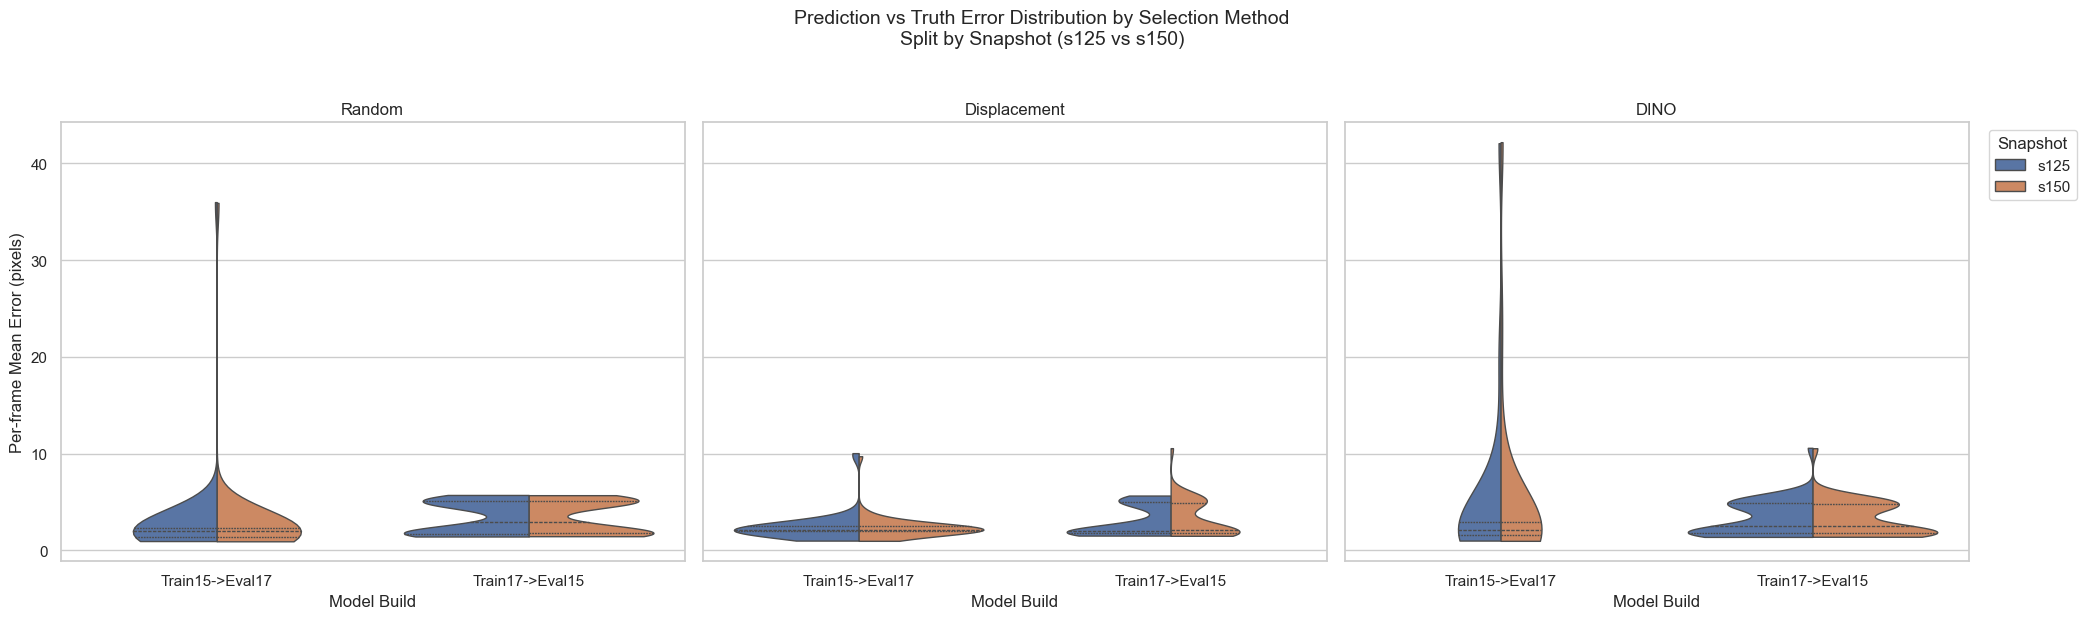

In [93]:
# Visualization: violin plots of prediction error distributions from current DeepLabCut2 layout.

import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

SAMPLES_ROOT_VIOLIN = Path(
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\SamplesForModelUpdate"
)

METHOD_CFG_VIOLIN = {
    "Random": {"dir": "RandomSamplesData", "sample_suffix": "-RandomSamplesPred.csv"},
    "Displacement": {"dir": "DisplacementSamplesData", "sample_suffix": "-DisplacementSamplesPred.csv"},
    "DINO": {"dir": "DinoSamplesData", "sample_suffix": "-DinoSamplesPred.csv"},
}

SNAPSHOTS_VIOLIN = [125, 150]
TRAIN_EVALS_VIOLIN = ["TrainT15_EvalT17", "TrainT17_EvalT15"]
MODEL_LABELS = {
    "TrainT15_EvalT17": "Train15->Eval17",
    "TrainT17_EvalT15": "Train17->Eval15",
}


def _snapshot_token_from_name(name: str):
    m = re.search(r"_s(\d+)-", str(name), flags=re.IGNORECASE)
    return int(m.group(1)) if m else None


def _find_per_frame_errors_csv(method: str, snapshot: int, train_eval: str):
    cfg = METHOD_CFG_VIOLIN[method]
    folder = SAMPLES_ROOT_VIOLIN / cfg["dir"] / train_eval
    if not folder.exists():
        return None

    sample_matches = sorted(folder.glob(f"*{cfg['sample_suffix']}"))
    sample_matches = [p for p in sample_matches if _snapshot_token_from_name(p.name) == int(snapshot)]
    if not sample_matches:
        return None

    sample_csv = sample_matches[0]
    error_name = sample_csv.name.replace(cfg["sample_suffix"], "-PerFrameErrors.csv")
    error_csv = folder / error_name
    if error_csv.exists():
        return error_csv

    alt = sorted(folder.glob("*-PerFrameErrors.csv"))
    alt = [p for p in alt if _snapshot_token_from_name(p.name) == int(snapshot)]
    return alt[0] if alt else None


rows = []
missing = []

for method in METHOD_CFG_VIOLIN:
    for snapshot in SNAPSHOTS_VIOLIN:
        for te in TRAIN_EVALS_VIOLIN:
            error_csv = _find_per_frame_errors_csv(method, snapshot, te)
            if error_csv is None:
                missing.append((method, snapshot, te, "missing_error_csv"))
                continue

            err_df = pd.read_csv(error_csv)
            if "mean_err_all" not in err_df.columns:
                missing.append((method, snapshot, te, "missing_mean_err_all"))
                continue

            vals = pd.to_numeric(err_df["mean_err_all"], errors="coerce").dropna()
            if vals.empty:
                missing.append((method, snapshot, te, "empty_values"))
                continue

            for v in vals:
                rows.append(
                    {
                        "method": method,
                        "snapshot": f"s{int(snapshot)}",
                        "model": MODEL_LABELS.get(te, te),
                        "error": float(v),
                    }
                )

plot_df = pd.DataFrame(rows)
print(plot_df.head())

if plot_df.empty:
    print("No per-frame error data found. Run Cell 28 first to generate *-PerFrameErrors.csv files.")
else:
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 3, figsize=(21, 6), sharey=True)

    method_order = ["Random", "Displacement", "DINO"]
    model_order = [MODEL_LABELS[x] for x in TRAIN_EVALS_VIOLIN]
    snapshot_order = [f"s{x}" for x in SNAPSHOTS_VIOLIN]

    for ax, method in zip(axes, method_order):
        sub = plot_df[plot_df["method"] == method].copy()

        if sub.empty:
            ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
            ax.set_title(method)
            ax.set_xlabel("Model")
            continue

        sns.violinplot(
            data=sub,
            x="model",
            y="error",
            hue="snapshot",
            order=model_order,
            hue_order=snapshot_order,
            split=True,
            inner="quart",
            cut=0,
            linewidth=1,
            ax=ax,
        )

        ax.set_title(method)
        ax.set_xlabel("Model Build")
        if ax is axes[0]:
            ax.set_ylabel("Per-frame Mean Error (pixels)")
        else:
            ax.set_ylabel("")

        if ax is not axes[-1]:
            leg = ax.get_legend()
            if leg is not None:
                leg.remove()

    last_leg = axes[-1].get_legend()
    if last_leg is not None:
        last_leg.set_title("Snapshot")
        last_leg.set_bbox_to_anchor((1.02, 1.0))
        last_leg._loc = 2

    fig.suptitle(
        "Prediction vs Truth Error Distribution by Selection Method\nSplit by Snapshot (s125 vs s150)",
        fontsize=14,
        y=1.03,
    )
    plt.tight_layout()
    plt.show()

    if missing:
        print("Missing or incomplete combinations:")
        for m in missing:
            print(" ", m)

C:\Users\Salle-Cineradio\AppData\Local\Temp\ipykernel_17568\1676298306.py:143: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.08, 1, 0.98])


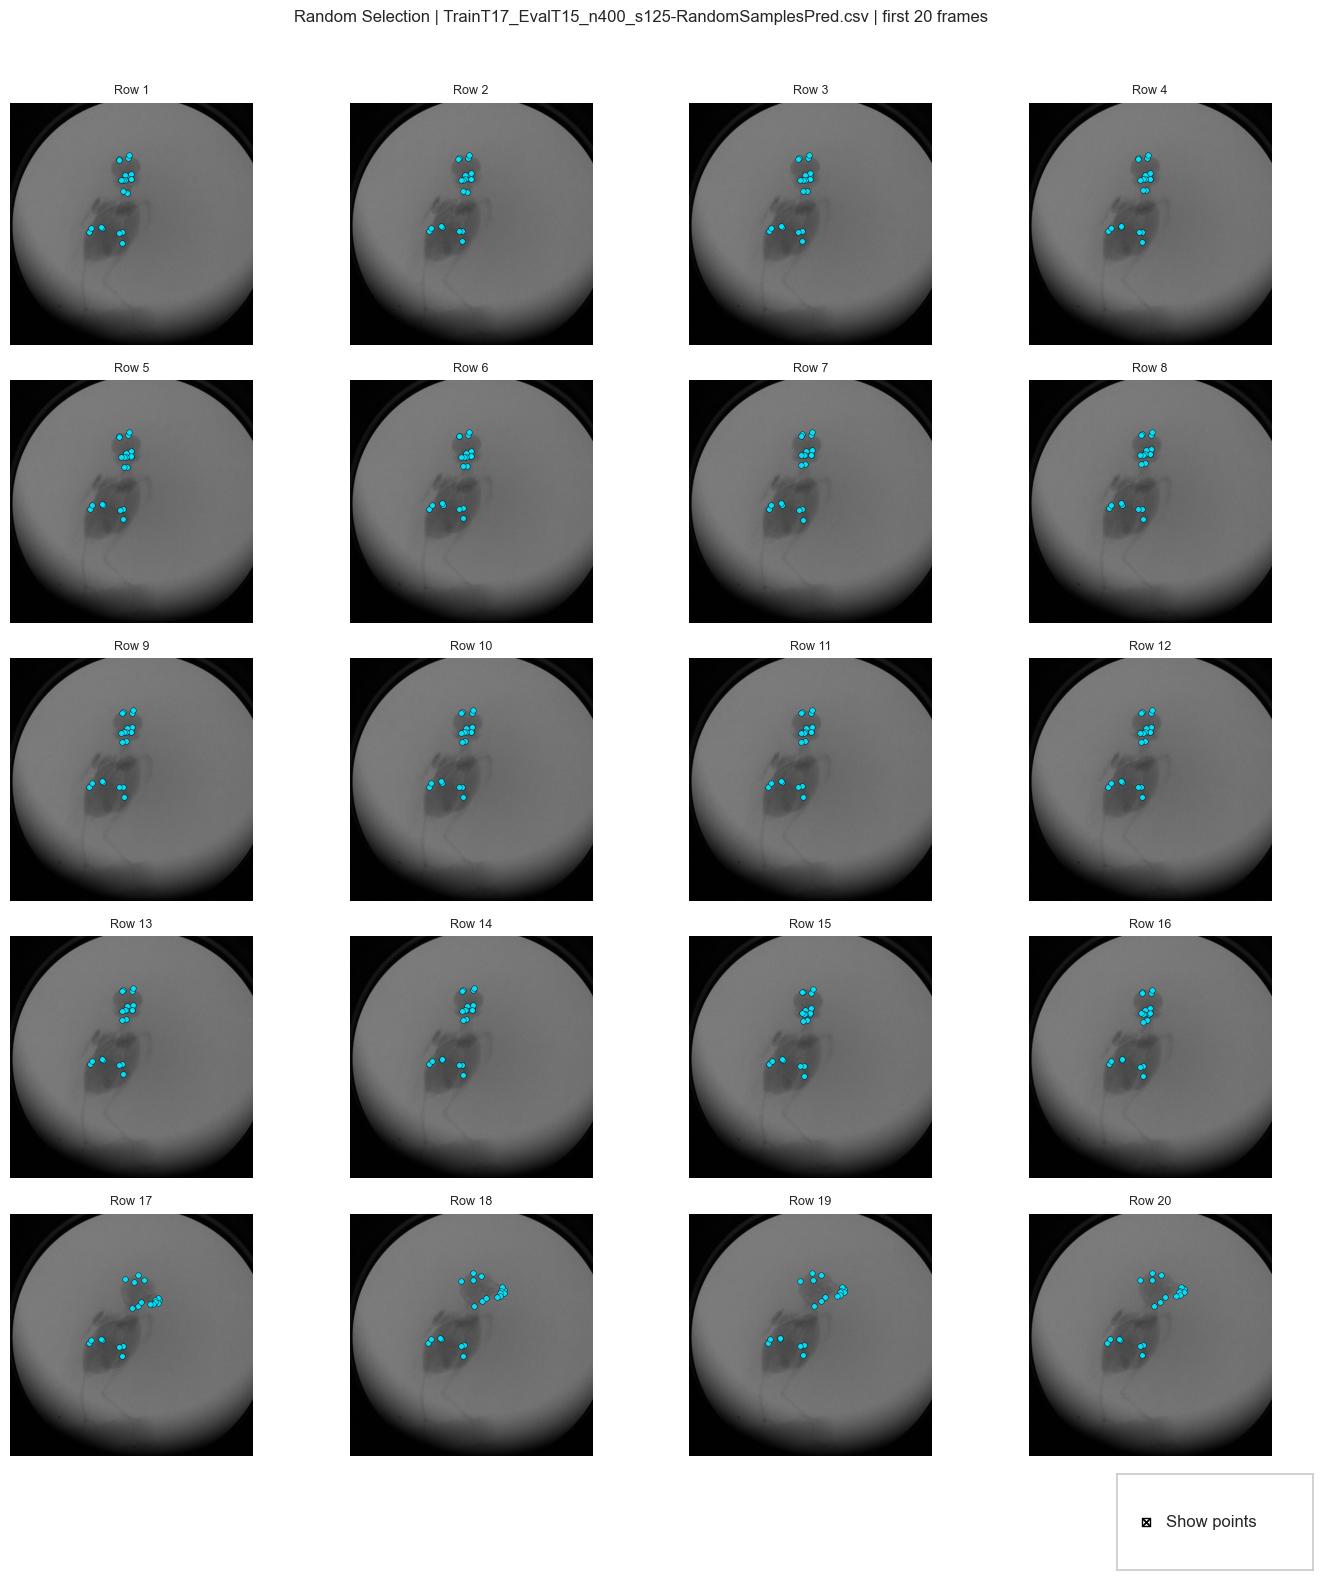

C:\Users\Salle-Cineradio\AppData\Local\Temp\ipykernel_17568\1676298306.py:143: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.08, 1, 0.98])


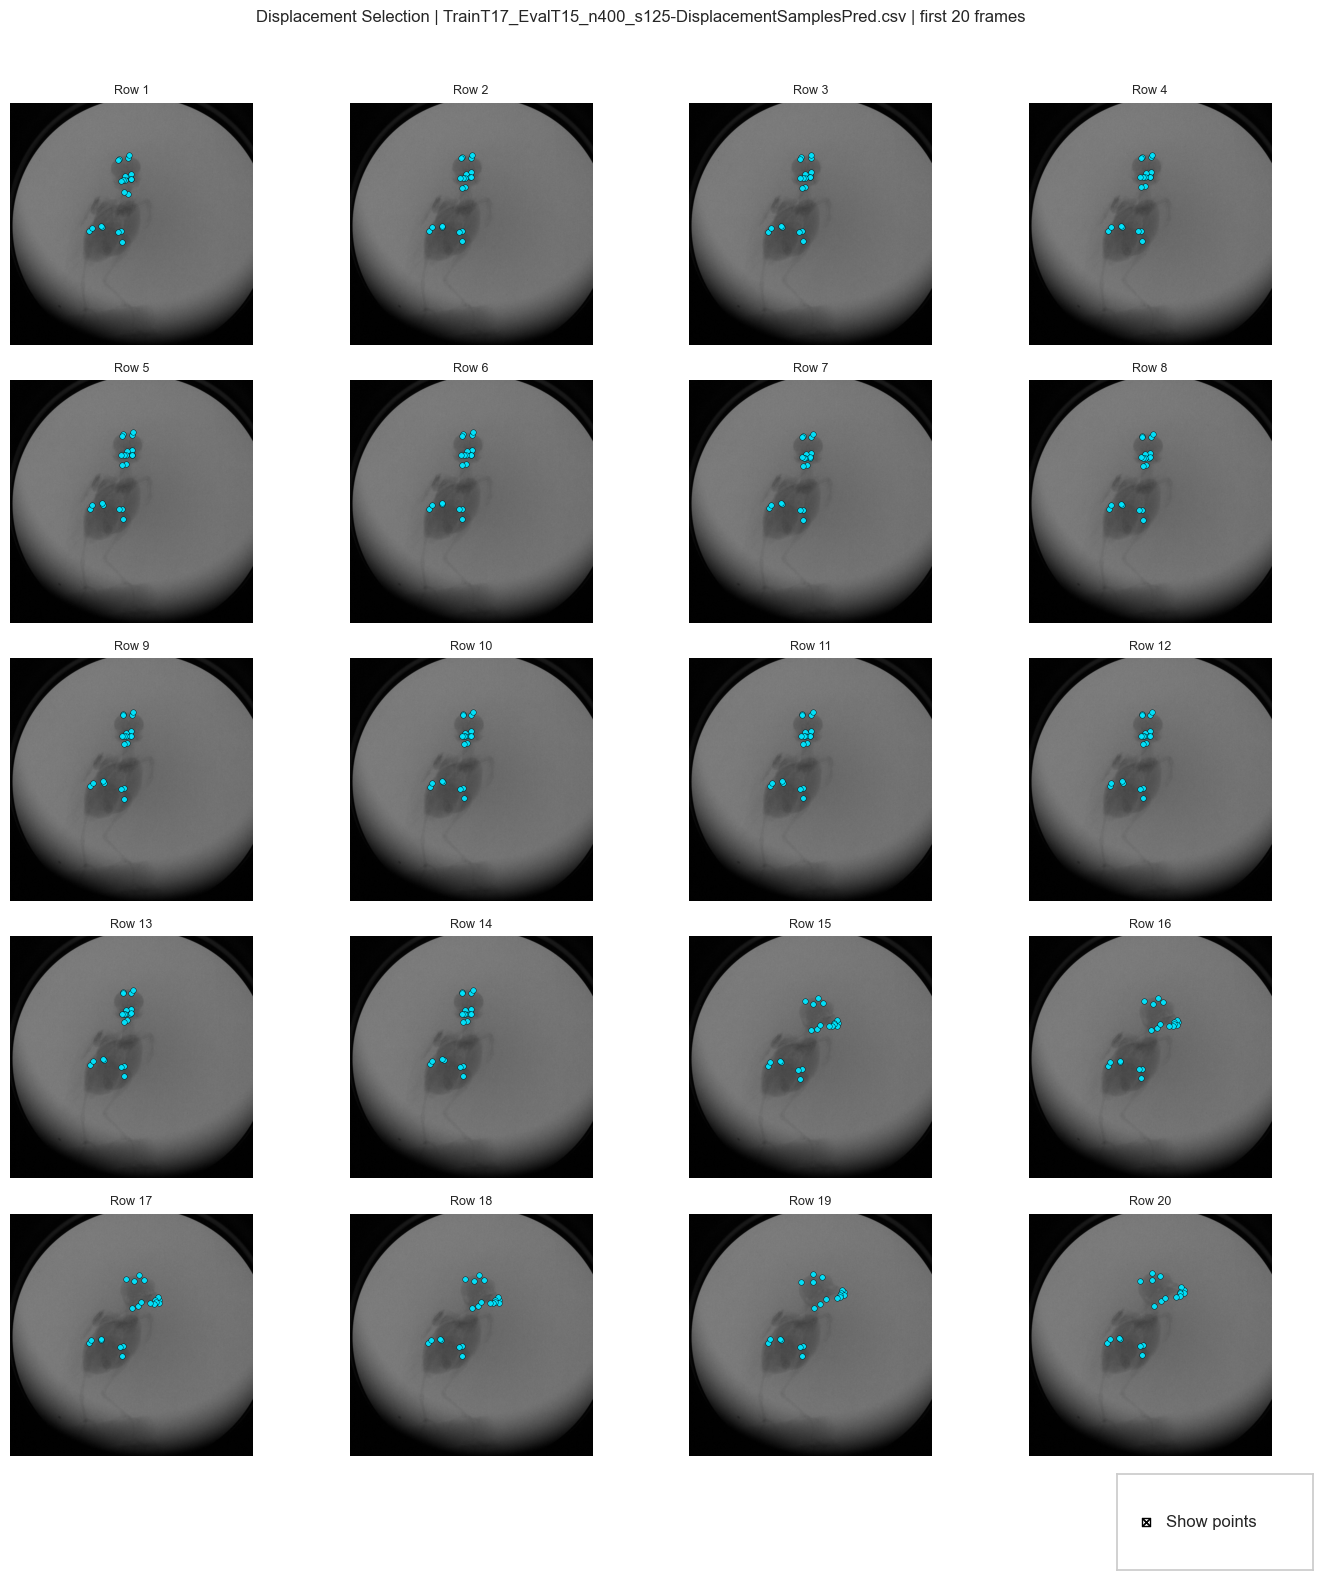

C:\Users\Salle-Cineradio\AppData\Local\Temp\ipykernel_17568\1676298306.py:143: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.08, 1, 0.98])


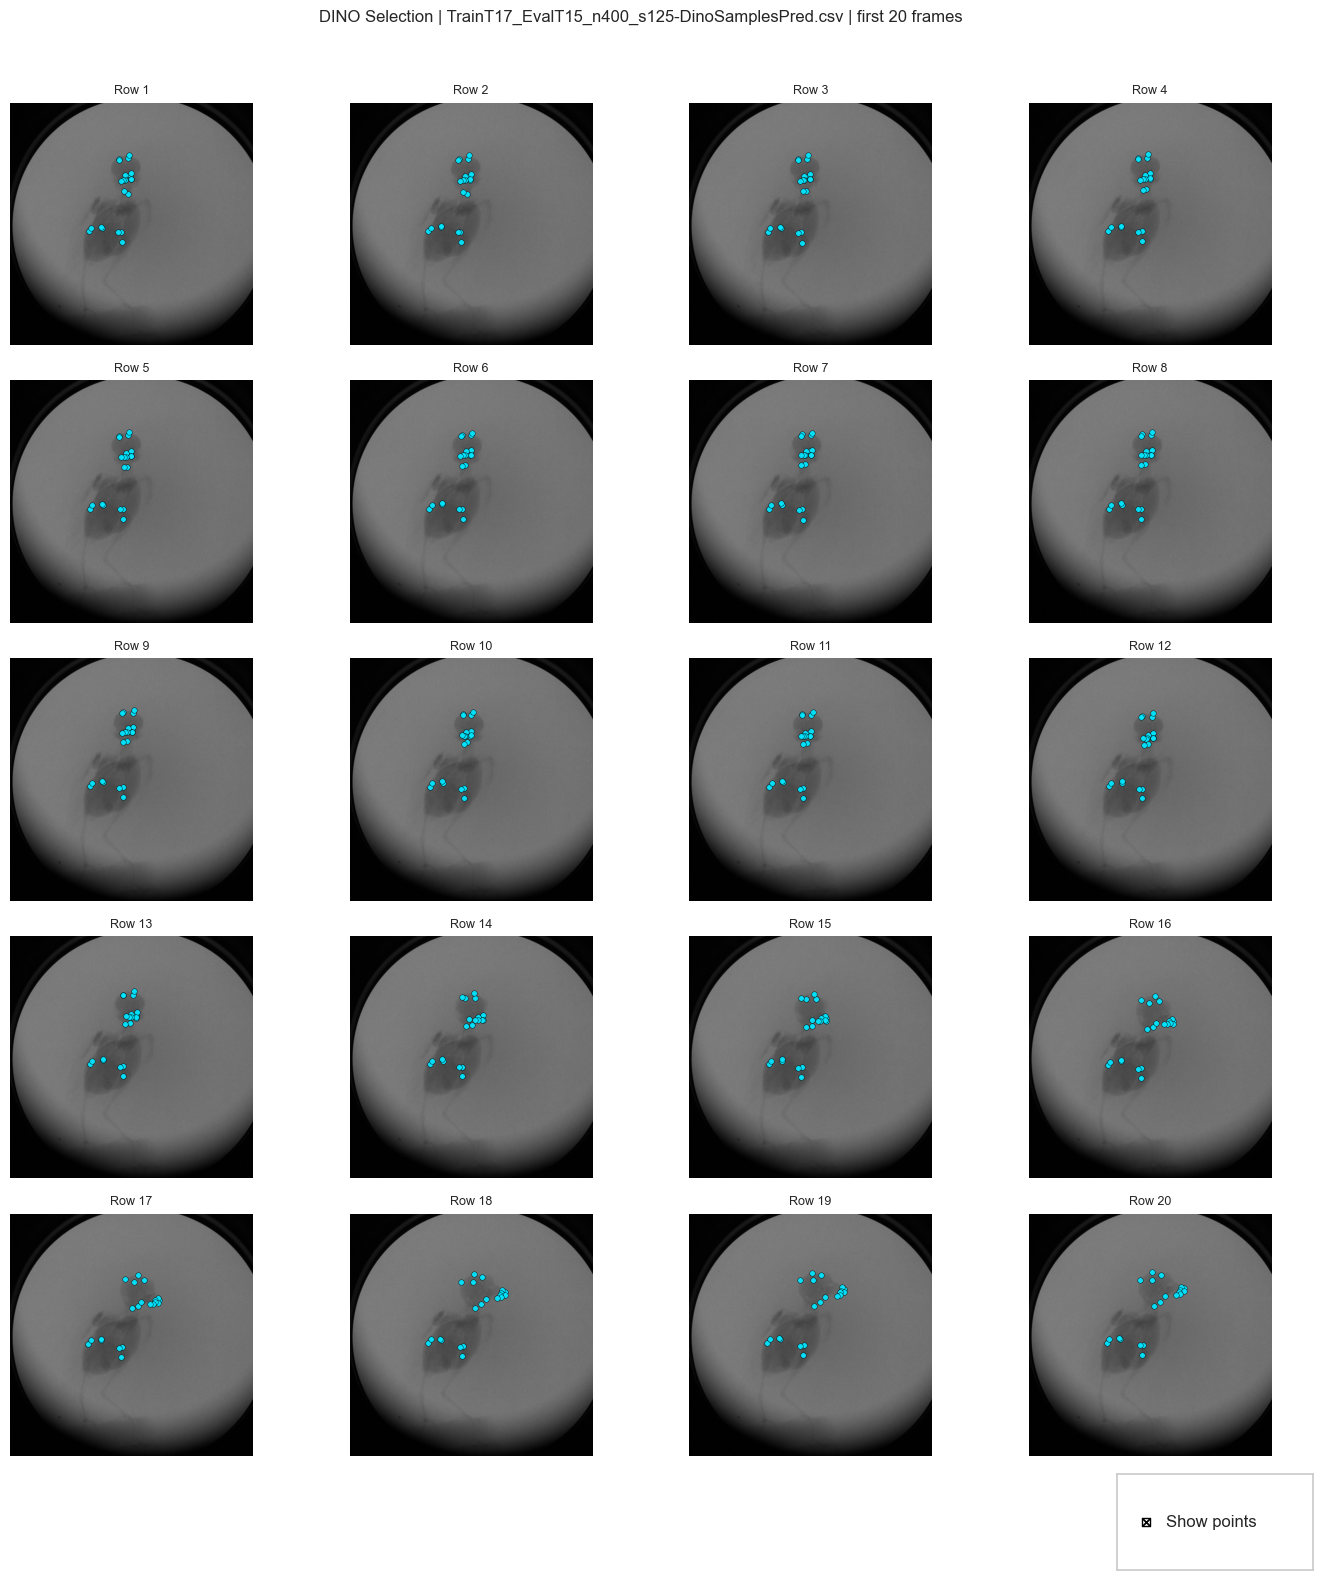

In [84]:
# Extra Visualization: 20-frame grids from exported sample CSVs (current DeepLabCut2 layout).

import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.widgets import CheckButtons
from PIL import Image

SAMPLES_ROOT_GRID = Path(
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\SamplesForModelUpdate"
)

GRID_METHOD_CFG = {
    "Random": {"dir": "RandomSamplesData", "suffix": "-RandomSamplesPred.csv"},
    "Displacement": {"dir": "DisplacementSamplesData", "suffix": "-DisplacementSamplesPred.csv"},
    "DINO": {"dir": "DinoSamplesData", "suffix": "-DinoSamplesPred.csv"},
}

GRID_TRAIN_EVAL = "TrainT17_EvalT15"
GRID_SNAPSHOT = 125


def _snapshot_token_from_name(name: str):
    m = re.search(r"_s(\d+)-", str(name), flags=re.IGNORECASE)
    return int(m.group(1)) if m else None


def _find_sample_csv_for_grid(method: str, train_eval: str, snapshot: int):
    cfg = GRID_METHOD_CFG[method]
    folder = SAMPLES_ROOT_GRID / cfg["dir"] / train_eval
    if not folder.exists():
        return None

    matches = sorted(folder.glob(f"*{cfg['suffix']}"))
    matches = [p for p in matches if _snapshot_token_from_name(p.name) == int(snapshot)]
    return matches[0] if matches else None


def _cam_xy_pairs_from_df(df, camera="cam1"):
    pat_x = re.compile(rf"(.+?)_{camera}_X$")
    pat_y = re.compile(rf"(.+?)_{camera}_Y$")

    x_map, y_map = {}, {}
    for c in df.columns:
        cs = str(c)
        mx = pat_x.match(cs)
        my = pat_y.match(cs)
        if mx:
            x_map[mx.group(1)] = cs
        if my:
            y_map[my.group(1)] = cs

    keys = sorted(set(x_map).intersection(y_map))
    return [(x_map[k], y_map[k]) for k in keys]


def _plot_selection_grid_from_csv(csv_path: Path, title, camera="cam1", nrows=5, ncols=4, n_show=20, show_points=True):
    if csv_path is None or not csv_path.exists():
        print(f"{title}: sample CSV not found")
        return

    df = pd.read_csv(csv_path).copy()
    if df.empty:
        print(f"{title}: empty CSV")
        return

    view_df = df.head(int(n_show)).copy().reset_index(drop=True)
    xy_pairs = _cam_xy_pairs_from_df(view_df, camera=camera)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 16))
    axes = np.asarray(axes).reshape(-1)
    overlay_artists = []

    for ax_i, ax in enumerate(axes):
        if ax_i >= len(view_df):
            ax.axis("off")
            continue

        row = view_df.iloc[ax_i]
        image_path = str(row.get("image_path", ""))

        if camera == "cam2" and isinstance(image_path, str):
            image_path = image_path.replace("Cam1", "Cam2").replace("cam1", "cam2")

        if image_path and os.path.isfile(image_path):
            try:
                with Image.open(image_path) as img:
                    ax.imshow(np.asarray(img.convert("RGB")))
            except Exception:
                ax.text(0.5, 0.5, "Image load failed", ha="center", va="center")
                ax.set_facecolor("#f3f3f3")
        else:
            ax.text(0.5, 0.5, "Image not found", ha="center", va="center")
            ax.set_facecolor("#f3f3f3")

        if xy_pairs:
            xs = []
            ys = []
            for x_col, y_col in xy_pairs:
                x = pd.to_numeric(row.get(x_col, np.nan), errors="coerce")
                y = pd.to_numeric(row.get(y_col, np.nan), errors="coerce")
                if np.isfinite(x) and np.isfinite(y):
                    xs.append(float(x))
                    ys.append(float(y))

            if xs and ys:
                scat = ax.scatter(
                    xs,
                    ys,
                    s=16,
                    c="#00e5ff",
                    edgecolors="black",
                    linewidths=0.3,
                    alpha=0.95,
                    zorder=3,
                )
                overlay_artists.append(scat)

        ax.set_title(f"Row {ax_i + 1}", fontsize=9)
        ax.axis("off")

    fig.suptitle(f"{title} | {csv_path.name} | first {min(len(view_df), n_show)} frames", fontsize=12, y=0.995)

    toggle_ax = fig.add_axes([0.84, 0.02, 0.14, 0.06])
    check = CheckButtons(toggle_ax, ["Show points"], [bool(show_points)])

    for artist in overlay_artists:
        artist.set_visible(bool(show_points))

    def _toggle(_label):
        if not overlay_artists:
            return
        visible = not overlay_artists[0].get_visible()
        for artist in overlay_artists:
            artist.set_visible(visible)
        fig.canvas.draw_idle()

    check.on_clicked(_toggle)
    plt.tight_layout(rect=[0, 0.08, 1, 0.98])
    plt.show()


for method_name in ["Random", "Displacement", "DINO"]:
    csv_path = _find_sample_csv_for_grid(method_name, GRID_TRAIN_EVAL, GRID_SNAPSHOT)
    _plot_selection_grid_from_csv(
        csv_path,
        title=f"{method_name} Selection",
        camera="cam1",
        nrows=5,
        ncols=4,
        n_show=20,
        show_points=True,
    )